# CHEM 273 — Project 2: Biased Random Walk of *E. coli*

**Team:** Aleyna Celebi, Dalila Gallegos, Emma Patrichi, Nisa Celebi, Tracy Doumit

---

You can just run this notbook top to bottom with `Cell > Run All` and it reproduces every result and figure in the report. (No files from the repository are needed)

**What the simulation does:** An *E. coli* cell cannot perceive a chemical gradient (it has one sensor so it only measures how much is here, right now). 
E. coli compares the concentration it senses now against the concentration four time steps ago, and uses the sign of that change to decide which way to swim. 
This notebook builds that model from the ground up and shows that it works: a population starting 77 µm from a food source closes to 4 µm, while an identical population that ignores the information drifts out to 101 µm.

## Imports

The only dependencies are numpy and matplotlib.

In [27]:
from abc import ABC, abstractmethod                                      # for abstract classes and required methods
from dataclasses import dataclass, asdict, field, replace                # For creating and modifying data classes
from pathlib import Path                                                 # For working with file and folder paths
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple  # For type hints

import matplotlib.pyplot as plt                                          # For creating plots and figures
from matplotlib.collections import LineCollection                        # For plotting multiple line segments
import numpy as np                                                       # For arrays and numerical calculations

%matplotlib inline
plt.rcParams["figure.dpi"] = 110                  # readable inline without being too big
np.set_printoptions(precision=3, suppress=True)   # suppress=True prints 0.001 rather than 1.0e-03

## 1. `config.py`: Settings
### What it Does: Every tunable number in one frozen dataclass, so five files cannot drift apart.

All simulation settings are stored together in one Config. Because it is frozen, its values cannot be accidentally changed after it is created. To change a setting, use replace(cfg, n_cells=1000), which creates a new Config while leaving the original unchanged.

In [28]:
# config.py -- every tunable number in the simulation, in one place.
# Part 1 of the assignment says shared parameters live in ONE file everyone imports, instead of five hardcoded copies drifting apart. This will be that file.
# Units are micrometers and seconds throughout, loosely matched to Huo et al. 2021 (their measured run speed was about 10 um/s).

# IMPORTANT NOTE:
# To CHANGE a value, do NOT edit it here!!! 
# Use dataclasses.replace(cfg, n_cells=1000), which returns a brand new Config and leaves the original untouched.



# frozen = True makes an instance READ-ONLY after it is built, so no module can change a shared setting halfway through a run (making results irreproducible)
class Config:
    """Every tunable number in the simulation."""

    # ---- geometry ----
    domain_half_width: float = 100.0     # domain is the square [-H, H] x [-H, H] in micrometers --> used by apply_boundary and initial_positions

    # ---- motion ----
    # One chemotaxis cycle = n_tumbles random steps, then one directed run.
    tumble_step: float = 1.0             # how far one random tumble step moves a bacterium, um
    run_length: float = 5.0              # how far one directed run step moves a bacterium, um --> LONGER than a tumble on purpose, so the bias wins on average and the cell actually climbs
    n_tumbles: int = 4                   # the sampling window --> the "4 * delta t" the assignment asks us to compare across

    # ---- chemotaxis decision ----
    ascend: bool = True                  # True climbs TOWARD higher concentration. The slide says "descent", which would swim cells away from food
    min_displacement: float = 1e-9       # displacement floor, um --> below this the 4 tumbles cancelled out and dividing by |d|^2 would blow up
    fallback: str = "previous"           # what to do when the 4 tumbles cancel --> "previous" reuses the last run direction, "random" picks a fresh one, "skip" sits still for this cycle

    sensing_noise: float = 0.0           # standard deviation of the noise added to every concentration reading. 0.0 means a PERFECT sensor, which is what we use for the headline result.
    biased: bool = True                  # False runs the UNBIASED CONTROL: same number of tumbles and runs, but the run direction is picked at random instead of from the gradient estimate.

    # ---- population ----
    n_cells: int = 100                   # N --> how many E. coli to simulate
    n_iterations: int = 200              # I, how many chemotaxis cycles each bacterium performs. One cycle = 4 tumbles + 1 run.
    start_mode: str = "uniform"          # where the bacteria begin --> "uniform" scatters them across the whole domain, "point" stacks them all at start_point, "ring" places them on a circle
    start_point: tuple[float, float] = (-70.0, -70.0)   # only read when start_mode is "point"
    start_radius: float = 80.0                          # only read when start_mode is "ring"

    # ---- boundary ----
    boundary: str = "none"               # "none" leaves the domain unbounded, "reflect" bounces bacteria off the walls, "wrap" teleports them to the opposite edge
                                         # GROUP DECISION: default is "none". Reflect piles cells against the walls and wrap teleports them, and BOTH distort the distance-from-source histogram, which is our headline figure.

    stop_at_source: bool = False         # False lets bacteria keep moving once they arrive
    capture_radius: float = 5.0          # only read when stop_at_source is True: how close counts as "arrived", um

    # ---- bookkeeping ----
    seed: int = 0                        # random seed --> ONE generator is built from this in main.py and passed down to everything, so a whole run reproduces from one number

    store_substeps: bool = False         # True keeps EVERY tumble position, not just the end of each cycle

    # Plain dict of every field, so a saved run can record the exact settings it used alongside its data
    def as_dict(self) -> dict:
        return asdict(self)

Config = dataclass(frozen=True)(Config)   # dataclass(frozen=True) returns a decorator, which is then called on the class --> that is why there are two sets of parentheses


# Presets, so nobody retypes these in five places.
DEFAULT = Config()                                 # the settings every module falls back to
SMALL = Config(n_cells=10)
MEDIUM = Config(n_cells=100)
LARGE = Config(n_cells=1000)

POPULATION_SIZES = (10, 100, 1000)                 # the three N values the assignment asks for
SNAPSHOT_ITERATIONS = (1, 10, 50, 100, 1000)       # the iteration counts we report statistics and draw histograms at.
                                                   # Lives here rather than in figures.py so the RESULTS TABLE and the HISTOGRAM FIGURE always show the same I values. Counts past the end of a run are skipped automatically.

## 2. `contracts.py`: The result container
### What it Does: `SimulationResult`, the one data structure that crosses file boundaries, plus save/load.

`SimulationResult` is the one data structure that crosses file boundaries. The simulation fills it in, the statistics read it, the plots draw it. Arrays throughout (N x I+1 x 2 positions), never a list of objects, so every statistic is one vectorized numpy call.

In [3]:
# contracts.py is complex in terms of crossing file boundaries:
    # simulate.py FILLS a SimulationResult in
    # experiments.py SAVES it and stats.py computes statistics on it
    # plotting.py READS it to draw the figures

# GROUP DECISION (Part 1, "What is in a SimulationResult"): ARRAYS
    # We chose positions shaped N x T x 2 and concentrations shaped N x T, over "a list of Bacterium objects", because stats.py needs to do vectorized numpy math over the whole population at once.
    # A list of objects would force a Python loop in every single statistic we compute.




class SimulationResult:
    """Everything one simulation run produced."""

    # ARRAY SHAPES, where N = number of bacteria, I = number of chemotaxis cycles, and the trailing 2 is always (x, y):
    positions: np.ndarray        # (N, I+1, 2) --> position at the END of each cycle. Index 0 along the middle axis is the STARTING position, which is why it's I+1 and not I.
    concentrations: np.ndarray   # (N, I+1)    --> the concentration each bacterium sensed at each of those positions
    run_directions: np.ndarray   # (N, I, 2)   --> the unit vector each bacterium ran along in each cycle. Useful for checking the bias points the right way.
    delta_c: np.ndarray          # (N, I)      --> C(t) minus C(t - 4*dt) for each cycle. This is the finite difference the whole algorithm rests on, so it's worth keeping.
    gradient_valid: np.ndarray   # (N, I) bool --> False wherever the 4 tumbles cancelled and the gradient estimate had to fall back
    field_name: str              # which concentration profile was used: linear, shallow, single_source, or competing_sources
    sources: np.ndarray          # (S, 2)      --> where the peaks are, COPIED from the field so plotting and stats never need the field object itself
    config: Dict[str, Any] = field(default_factory=dict)   # the exact Config used, as a plain dict --> a saved run records its own settings, so we can never wonder which parameters produced a figure
    substeps: Optional[np.ndarray] = None                  # (N, I, n_tumbles+2, 2) the full within-cycle path, or None --> only stored when config['store_substeps'] is True

    # Every array above is PREALLOCATED by run_simulation with np.empty and filled by index.
    # default_factory=dict is needed because a plain {} as a default would be SHARED by every SimulationResult ever made --> the factory builds a fresh empty dict each time.


    # ---- shape helpers (so callers never have to remember which axis is which) ----

    def n_cells(self) -> int:
        return self.positions.shape[0]      # axis 0 is the bacterium axis
    n_cells = property(n_cells)             # property() means callers write result.n_cells, not result.n_cells()

    def n_iterations(self) -> int:
        return self.positions.shape[1] - 1  # minus 1 because index 0 is the starting position, not a completed cycle
    n_iterations = property(n_iterations)


    # ---- STEP 24: the derived quantities stats.py and plotting.py both need ----

    # Straight-line distance from every bacterium to ONE source, at EVERY iteration. Returns shape (N, I+1).
    # THIS IS THE HEADLINE MEASUREMENT of the whole project: the assignment asks how the distance-from-source distribution narrows as N and I increase, and this is the array that answers it.
    def distances_to_source(self, source_index: int = 0) -> np.ndarray:
        src = np.atleast_2d(self.sources)[source_index]        # atleast_2d guards against a field that returned a bare (2,) instead of (S, 2), so this works either way
        return np.linalg.norm(self.positions - src, axis=-1)   # subtract the source from every position (broadcasting), then norm along the LAST axis to collapse each (dx, dy) pair into one distance

    # Distance to whichever source happens to be CLOSEST, shape (N, I+1).
    # Needed for competing_sources, where "distance from THE source" is ambiguous --> a bacterium that found the second peak has not failed, it just picked the other basin.
    def distances_to_nearest_source(self) -> np.ndarray:
        src = np.atleast_2d(self.sources)                                    # (S, 2)
        diff = self.positions[:, :, None, :] - src[None, None, :, :]         # the None entries insert axes so EVERY position is paired with EVERY source --> (N, I+1, S, 2), no loop
        return np.linalg.norm(diff, axis=-1).min(axis=-1)                    # distance to each source, then keep the smallest one per bacterium per iteration

    # Vector from start to finish for each bacterium, shape (N, 2). Averaged over the population this shows the NET DRIFT direction, which is what proves the walk is biased on a linear field.
    def net_displacement(self) -> np.ndarray:
        return self.positions[:, -1, :] - self.positions[:, 0, :]

    # Check the shapes agree BEFORE handing this to another file, so a mistake surfaces at the handoff instead of inside somebody else's figure two hours later.
    def validate(self) -> None:
        n, t_plus_1, d = self.positions.shape
        assert d == 2, f"positions must be 2D, got last dim {d}"
        assert self.concentrations.shape == (n, t_plus_1), f"concentrations {self.concentrations.shape} != expected {(n, t_plus_1)}"
        assert self.run_directions.shape == (n, t_plus_1 - 1, 2)   # one FEWER than positions, because index 0 of positions is the start, not a cycle
        assert self.delta_c.shape == (n, t_plus_1 - 1)
        assert self.gradient_valid.shape == (n, t_plus_1 - 1)
        assert np.atleast_2d(self.sources).shape[1] == 2
        assert np.isfinite(self.positions).all(), "non-finite positions --> something divided by zero or diverged"   # catches NaN and inf, which numpy would otherwise carry silently into every plot





    # ---- STEP 26: saving and loading, so figures never have to rerun a simulation ----

# RERUNNING SIMULATION FOR EVERY PLOT IS INEFFICIENT:
    # We can try saving multiple NumPy arrays in a single file with np.savez_compressed() and np.load()
    # configuration dictionary can be converted to text with JSON
    # @classmethod can act as an alternative constructor
    # @dataclass to generate the class constructor automatically
        # sources: https://numpy.org/doc/stable/user/absolute_beginners.html, https://numpy.org/doc/stable/reference/generated/numpy.savez_compressed.html,
                 # https://numpy.org/doc/stable/reference/generated/numpy.load.html, https://numpy.org/doc/stable/user/how-to-io.html,
                 # https://docs.python.org/3/library/json.html, https://docs.python.org/3/reference/compound_stmts.html#the-with-statement,
                 # https://docs.python.org/3/tutorial/controlflow.html#unpacking-argument-lists, https://docs.python.org/3/library/functions.html#classmethod
                 # https://docs.python.org/3/library/dataclasses.html

# This step of code lets the program run a simulation once, save all its resulys, and reload them later for analysis/plotting
    # SimulationResult in memory
             #↓ save()
    #compressed results.npz file
             #↓ load()
    #new SimulationResult in memory

    # Write everything to ONE compressed .npz file.
    # experiments.py owns the code that CALLS this, but the FORMAT lives here next to the fields, so save and load can never drift apart and disagree about what is in the file.
    # .npz is numpy's own zipped archive format: it stores named arrays, compresses them, and loads them back with the exact same dtype and shape.
    def save(self, path) -> None:
        import json
        payload = dict(
            positions=self.positions,
            concentrations=self.concentrations,
            run_directions=self.run_directions,
            delta_c=self.delta_c,
            gradient_valid=self.gradient_valid,
            sources=np.atleast_2d(self.sources),
            field_name=np.array(self.field_name),            # npz stores ARRAYS, so the string is wrapped in a 0-dimensiomal array to get it through
            config_json=np.array(json.dumps(self.config)),   # same problem for the config dict --> json.dumps turns it into one string, which then goes in as a 0-d array
        )
        if self.substeps is not None:
            payload["substeps"] = self.substeps              # only written when it exists, so files stay small by default
        np.savez_compressed(path, **payload)                 # ** unpacks the dict into keyword arguments, so each key becomes the name of an array inside the archive

    # Rebuild a SimulationResult from a file written by save().
    # Disallow loading pickled Python-object arrays. Pickle deserialization can execute arbitrary code, so allow_pickle=False is safer for untrusted files
    # allow_pickle stays False so a data file can NEVER execute code when we open it
    # when allow_pickle is false, the .npz file should contain ordinary NumPy arrays numbrs and booleans rather than arbitrary Python objects
    def load(cls, path) -> "SimulationResult":
        import json
        with np.load(path, allow_pickle=False) as z:         # with allow_pickle=False, avoids unsafe Python-object deserialization. `with` closes the file if error occurs, even half-way through
            return cls(
                positions=z["positions"],
                concentrations=z["concentrations"],
                run_directions=z["run_directions"],
                delta_c=z["delta_c"],
                gradient_valid=z["gradient_valid"],
                field_name=str(z["field_name"]),             # unwrap the 0-d array back into a normal string
                sources=z["sources"],
                config=json.loads(str(z["config_json"])),    # and the json string back into a dict
                substeps=z["substeps"] if "substeps" in z.files else None,   # z.files lists what is actually in the archive, so an old file saved without substeps still loads
            )
    load = classmethod(load)   # classmethod() means it is called on the CLASS: SimulationResult.load(path). It has to be, because there is no instance yet (that is the whole point of loading one)

SimulationResult = dataclass(SimulationResult)   # dataclass() writes __init__ from the annotations above, so we don't have to write "self.positions = positions" multiple times

## 3. `fields.py`: The chemical environment
### What it Does: The chemical environment: C(x, y) for the shallow ramp, one source, and two competing sources.

Three concentration profiles: a shallow ramp, one food source, and two competing sources.

**The key distinction:** `concentration(xy)` is what a real cell can smell and is the only thing the simulation may call. `gradient(xy)` is the exact answer from calculus, which no real bacterium could perceive -- it exists purely as the answer key the tests grade the cell's estimate against.

In [4]:
# This file defines the chemical environment that bacteria swim through.
# Purpose: At position (x, y), how much attractant is there? (the function C(x, y)).
# 3 Versions: 1) Shallow ramp, 2) One food source, 3) Two competing food sources.
#   Each of the 3 versions is a subclass of ConcentrationField.

# Two methods per field, used by different files in this project:
#   1) concentration(xy):
        # What a cell can smell(the only thing the cell is allowed to sense).
        # simulate.py (the biased random walk) calls this to get the concentration at the cell's current position.
#   2) gradient(xy):
        # The uphill direction (towards higher concentration of food source), from the following equation:.
                # grad C = ( dC/dx , dC/dy )
            # Each field has its own, since each has its own C:
                # LinearGradient    grad C = g                        (a plane: same slope everywhere)
                # GaussianSource    grad C = -C (x - x_s) / sigma^2   (chain rule on the exponential)
                # CompetingSources  the per-source Gaussian gradients, added up
        # TESTS ONLY, never call this from simulate.py(the biased random walk) since an cell cannot perceive the gradient;
        # it has to estimate it from how concentration changed over the last 4 tumbles.
        # gradient(xy) is the answer key we grade estimate_gradient() (the cell's guess) against.



# Will allow simulate.py to accept ANY field without knowing which one it got.
# ABC blocks instantiation until every abstract method is filled in, (a half-finished field can't reach simulation)
class ConcentrationField(ABC):
    """Interface every concentration field obeys."""

    name = "field"      # short ID for filenames and plot titles; subclasses override

    # The only method the simualted bacterium may call.
    def concentration(self, xy: np.ndarray) -> np.ndarray: ...
    concentration = abstractmethod(concentration)

    # The exact gradient of C from the equation measures which way and speed the concentration rises
    # equation = the pair of partial derivatives:    grad C = ( dC/dx , dC/dy )
    # There is no one formula here in the base class -- each subclass differentiates its own C
    # In simulate.py, DO NOT CALL gradient() since the cell cannot perceive the gradient; 
    # it has to estimate it from how concentration changed over the last 4 tumbles.
    # Only ours test will call it to check estimate_gradient() against the right answer
    def gradient(self, xy: np.ndarray) -> np.ndarray: ...
    gradient = abstractmethod(gradient)


    # Where the peaks are. stats.py measures "distance from source" against this, so every field has to name its own target(s)
    def sources(self) -> np.ndarray:
        return np.zeros((1, 2))    # (num of sources(S) == 1, 2D position x & y)
    sources = property(sources)    # make sources readable. property() means callers write f.sources, not f.sources() 
                                   # with () f.sources() would get the function itslef, not the answer)

 
    # -- helpers the base class provides; subclasses inherit these -------------------------------------------------
    

    # Every public method starts by calling this, so bad input fails here with a clear message
    # instead of as a broadcasting error deep in the math.
    def _as_points(xy) -> np.ndarray:
        arr = np.asarray(xy, dtype=float)   # accept lists/ints; force float
        if arr.shape[-1] != 2:              # last axis must be (x, y)
            raise ValueError(f"expected last axis of size 2, got {arr.shape}")
        return arr
    _as_points = staticmethod(_as_points)   # staticmethod() = no self needed. Leading _ marks it internal

    # The measuring instrument: dC/dx ~ [C(x+h,y) - C(x-h,y)] / 2h
    # Deliberately dumb and obviously correct, so it can be trusted to check the hand-derived calculus in each subclass. Tests only.
    # "Central" means we step BOTH ways and split the difference, which cancels the leading error term and beats a one-sided step.
    def numerical_gradient(self, xy, h: float = 1e-5) -> np.ndarray:
        p = self._as_points(xy)                     # validate and convert the input
        ex = np.zeros_like(p)                       # an all-zeros array shaped like p
        ex[..., 0] = h                              # put h in the x slot only, so ex is a tiny nudge along x
        ey = np.zeros_like(p)                       # same again for y
        ey[..., 1] = h                              # ey is a tiny nudge along y
        dx = (self.concentration(p + ex) - self.concentration(p - ex)) / (2 * h)   # one central difference in x, evaluated for ALL points at once
        dy = (self.concentration(p + ey) - self.concentration(p - ey)) / (2 * h)   # same in y
        return np.stack((dx, dy), axis=-1)          # glue the two into (..., 2) so the shape matches what gradient() returns

    # (X, Y, C) grids for plotting.py's contour plots. Lives here, not in plotting.py, so the figure and the simulation read the same C(x, y).
    def meshgrid(self, half_width: float = 100.0, n: int = 200
                 ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        axis = np.linspace(-half_width, half_width, n)      # n evenly spaced values from -H to +H
        X, Y = np.meshgrid(axis, axis)                      # two (n, n) grids holding every x and every y
        C = self.concentration(np.stack((X, Y), axis=-1))   # stack into (n, n, 2) so the SAME concentration() handles the grid and returns (n, n)
        return X, Y, C                                      # exactly the three arrays plt.contourf wants


# =========================================================================
# [2] [3] write this second
# =========================================================================

class LinearGradient(ConcentrationField):
    """Shallow ramp:  C = c0 + g . (x - x_ref)"""

    # The validation field, and the anchor for the whole test suite: its gradient is the same vector everywhere, so the right answer can be checked on paper.
    # That is why it is written before any curved field. Doubles as the "shallow gradient" profile required by the spec if the slope is small.

    name = "linear"

    # Arguments with defaults, not hardcoded numbers, so the ramp can be changed without editing this file.
    def __init__(self, slope: Sequence[float] = (0.01, 0.0),
                 c0: float = 1.0, reference: Sequence[float] = (0.0, 0.0)):
        self.slope = np.asarray(slope, dtype=float).reshape(2)           # slope --> g, the constant gradient vector; reshape(2) errors loudly if someone passes 3 numbers
        self.c0 = float(c0)                                              # c0 --> the concentration AT the reference point
        self.reference = np.asarray(reference, dtype=float).reshape(2)   # reference --> x_ref, the one point where C is exactly c0

    # C = c0 + g.(x - x_ref) at every input point.
    # Hand checked: slope=(2,3), c0=5, ref=(1,1) -> C(2,1) must be 7.0
    def concentration(self, xy):
        p = self._as_points(xy)                              # validate shape first
        return self.c0 + (p - self.reference) @ self.slope   # @ is the dot product; it contracts the last axis, so (..., 2) @ (2,) gives (...) for every point at once

    # A plane has the same slope everywhere, so nothing is computed (just repeat `slope` to match input shape)
    def gradient(self, xy):
        p = self._as_points(xy)                              # only needed for its SHAPE, the values are irrelevant here
        return np.broadcast_to(self.slope, p.shape).copy()   # broadcast_to makes a cheap read-only view; .copy() turns it into a normal writable array callers can modify

    # A plane has no true maximum, but stats.py measures distance-from-source for every field. Report a point far uphill so that metric still works.
    def sources(self):
        direction = self.slope / (np.linalg.norm(self.slope) or 1.0)   # `or 1.0` guards a completely flat field: norm would be 0.0, which is false, so we divide by 1 instead of producing NaN
        return (100.0 * direction).reshape(1, 2)                       # reshape to (1, 2): a list holding one point, so callers never special-case the count
    sources = property(sources)


# =========================================================================
# [5] write this third (the first field checked by numerical_gradient)
# =========================================================================

class GaussianSource(ConcentrationField):
    """Single source:  C = A exp(-|x - x_s|^2 / (2 sigma^2))"""

    # A food pellet dissolving in still water: concentration is highest at the source and falls off smoothly with distance. This is the main field for the headline result.
    # The Gaussian is not arbitrary; it's the solution to the 2D diffusion equation for a point release, with sigma^2 = 2Dt, so the smell spreads as sqrt(t).
    # Differentiating by the chain rule gives  grad C = -C (x - x_s) / sigma^2
    # (x - x_s) points AWAY from the source and the minus sign flips it, so grad C points INWARD. That is why gradient ASCENT walks cells toward food.

    name = "single_source"

    def __init__(self, center: Sequence[float] = (0.0, 0.0),
                 amplitude: float = 100.0, sigma: float = 50.0,
                 baseline: float = 0.0):
        self.center = np.asarray(center, dtype=float).reshape(2)   # center --> x_s, where the food is
        self.amplitude = float(amplitude)                          # amplitude --> A, the peak concentration right at the source
        self.sigma = float(sigma)                                  # sigma --> width; how far the smell carries. Too small and distant cells sense nothing at all.
        self.baseline = float(baseline)                            # baseline --> background concentration far away from any source

    # Check by confirming C(center) == amplitude + baseline.
    def concentration(self, xy):
        p = self._as_points(xy)                                            # validate the shape first
        d = p - self.center                                                # d --> (..., 2) offset from the source to each point
        r2 = np.einsum("...i,...i->...", d, d)                             # |d|^2 summed over the last axis; einsum fuses the multiply and the sum in one pass, and works for (2,), (N,2) and (200,200,2) alike
        return self.baseline + self.amplitude * np.exp(-r2 / (2.0 * self.sigma ** 2))   # the Gaussian itself

    # -C (x - x_s) / sigma^2. First real calculus in the file, and what numerical_gradient exists to verify.
    def gradient(self, xy):
        p = self._as_points(xy)
        d = p - self.center                                                # same offset as above
        r2 = np.einsum("...i,...i->...", d, d)                             # same |d|^2, computed inline rather than by calling concentration() again, which would redo all of this work
        bump = self.amplitude * np.exp(-r2 / (2.0 * self.sigma ** 2))      # C minus the baseline; a constant baseline contributes nothing to a derivative
        return -(bump / self.sigma ** 2)[..., None] * d                    # [..., None] adds a trailing axis so the scalar per point broadcasts against d's (x, y) pair

    # The peak is exactly the center; reshape to (1, 2).
    def sources(self):
        return self.center.reshape(1, 2)
    sources = property(sources)


# =========================================================================
# [7] write this last of the three
# =========================================================================

class CompetingSources(ConcentrationField):
    """Sum of several Gaussians with different strengths."""

    # The population should SPLIT, with the saddle point between the peaks acting as a watershed.
    # Cells starting on either side climb into different basins, so keep the amplitudes unequal and one basin visibly wins.
    # VALIDATED THIS by confirming it equals the sum of the GaussianSources. (LinearGradient and GaussianSource are checked against numerical_gradient; 
    # CompetingSources is checked against the sum of parts instead, because there's no independent right answer for it.)

    name = "competing_sources"

    def __init__(self,
                 centers: Sequence[Sequence[float]] = ((-50.0, 0.0), (50.0, 0.0)),
                 amplitudes: Sequence[float] = (100.0, 60.0),
                 sigmas: Sequence[float] = (30.0, 30.0),
                 baseline: float = 0.0):
        self.centers = np.asarray(centers, dtype=float).reshape(-1, 2)      # (S, 2); reshape(-1, 2) means "however many rows, 2 columns"
        self.amplitudes = np.asarray(amplitudes, dtype=float).reshape(-1)   # (S,) one peak height per source
        self.sigmas = np.asarray(sigmas, dtype=float).reshape(-1)           # (S,) one width per source
        self.baseline = float(baseline)
        # Catch a mismatched setup HERE, at construction, rather than as a confusing broadcasting error later inside a 1000-cell run.
        if not (len(self.centers) == len(self.amplitudes) == len(self.sigmas)):
            raise ValueError("centers, amplitudes and sigmas must be same length")

    # The per-source pieces both concentration() and gradient() need, factored out so the exponential is computed once and the two formulas cannot drift apart.
        # returns  d    (..., S, 2)  displacement from each source
                # bump (..., S)     each source's Gaussian value
    def _bumps(self, p: np.ndarray):
        d = p[..., None, :] - self.centers                                # [None] inserts an axis making p (..., 1, 2), which broadcasts against (S, 2) to pair every point with every source, no loop
        r2 = np.einsum("...i,...i->...", d, d)                            # (..., S) squared distance to each source
        bump = self.amplitudes * np.exp(-r2 / (2.0 * self.sigmas ** 2))   # the (S,) parameters broadcast across the source axis
        return d, bump

    # Concentrations from independent sources simply add. Sum bump over the S axis.
    def concentration(self, xy):
        p = self._as_points(xy)
        _, bump = self._bumps(p)                    # the underscore means we are deliberately ignoring d here
        return self.baseline + bump.sum(axis=-1)    # axis=-1 is the source axis

    # Gradients add too, because differentiation is linear. Apply the GaussianSource formula per source, then sum over the S axis.
    def gradient(self, xy):
        p = self._as_points(xy)
        d, bump = self._bumps(p)                                     # here we need both pieces
        per_source = -(bump / self.sigmas ** 2)[..., None] * d       # (..., S, 2) each source's own gradient contribution
        return per_source.sum(axis=-2)                               # axis=-2 is the source axis; axis=-1 is x/y, which we must keep

    # Already stored as (S, 2); return as-is.
    def sources(self):
        return self.centers
    sources = property(sources)


# =========================================================================
# [8] Registry -- lets main.py pick a field by name from the command line
# =========================================================================
# Values are lambdas, not instances, so each make_field() call returns a FRESH object. Sharing one instance across a sweep would let a mutation in one run leak into the next.

FIELDS = {
    "linear": lambda: LinearGradient(slope=(0.02, 0.01)),
    "shallow": lambda: LinearGradient(slope=(0.001, 0.0005)),   # same class, gentler slope -- this is the "shallow gradient" profile the spec requires
    "single_source": lambda: GaussianSource(),
    "competing_sources": lambda: CompetingSources(),
}


# The only way main.py creates a field. On a bad name, raise with the list of valid options rather than a bare KeyError that tells the user nothing.
def make_field(name: str) -> ConcentrationField:
    if name not in FIELDS:
        raise KeyError(f"unknown field {name!r}; choose from {sorted(FIELDS)}")
    return FIELDS[name]()   # call the lambda, which builds a new instance

## 4. `agents.py`: The movement layer
### What it Does: The movement layer. Moves bacteria; never decides which way.

Moves bacteria and nothing else. It never sees a concentration and never decides which way to go.

All N bacteria are held as arrays rather than as N separate objects. At N=1000 over 1000 cycles that is about 5 million position updates: the array version takes ~0.45 s, a per-object Python loop takes ~36 s.

In [5]:
# agents.py -- the movement layer.
# The MOVEMENT layer. This file knows how to move bacteria.
# It does not know what a concentration is, and it never decides which way to go --> simulate.py works out the direction and hands it in. This file only gets the geometry right.

# GROUP DECISION (Part 1): For speed we chose to use vectorized arrays rather than python objects.
                         # (we hold all N bacteria as ARRAYS (the Population class), not as N separate Python objects)





# ---------------------------------------------------------------------------
# Steps 12, 13, 14: Direction Helpers
# ---------------------------------------------------------------------------
# These live at module level (not inside Population) so the tests can call them directly with made-up inputs, instead of having to build a whole population first


# n uniformly random 2D unit vectors, shape (n, 2)
    # rng: the shared np.random.Generator passed down from main.py --> every random number in the project comes from this one object, which makes a run reproducible from one seed
    # n:   how many direction vectors we want
def random_unit_vectors(rng: np.random.Generator, n: int) -> np.ndarray:
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)                # theta --> one random heading ANGLE per bacterium, drawn uniformly on [0, 2pi), so no direction is preferred over any other
    return np.stack((np.cos(theta), np.sin(theta)), axis = -1)     # cos and sin of an angle always give a vector of length exactly 1, so we don't have to normalize afterwards. axis = -1 pairs them into (x, y)


# Random unit vectors with ANY leading shape, result (*shape, 2)
# This is the version tumble() needs: it draws all N bacteria x all 4 tumble steps in a single call, giving (N, 4, 2), instead of calling random_unit_vectors four times.
def random_unit_grid(rng: np.random.Generator, *shape: int) -> np.ndarray:
    theta = rng.uniform(0.0, 2.0 * np.pi, size=shape)            # size can be (N,) or (N, 4) or anything else --> numpy fills whatever shape we ask for
    return np.stack((np.cos(theta), np.sin(theta)), axis = -1)     # adds the trailing axis of size 2, so (N, 4) angles become (N, 4, 2) vectors


# Row-wise normalize: divide every vector by its own lengtth so it becomes length 1, leaving near-zero rows as ZERO instead of NaN
# A zero row means that this bacterium has no direction this cycle, which is a valid state in our model, not an error --> so it must not become NaN and mess-up everything downstream
def normalize(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norm = np.linalg.norm(v, axis = -1, keepdims = True)                    # length of each row. keepdims = True keeps the trailing axis so the shape is (N, 1) and the division broadcasts against (N, 2)
    return np.divide(v, norm, out = np.zeros_like(v), where = norm > eps)   # where= tells numpy to SKIP the rows that would divide by ~0, and out= says what those skipped rows should contain instead (zeros)


# ---------------------------------------------------------------------------
# Step 16: Domain Boundary
# ---------------------------------------------------------------------------

# Enforce the domain rule for every position at once. Vectorized and branch-free per element --> the `if`s below choose a RULE once, they do not loop over bacteria.
# GROUP DECISION: the default is "none"(unbounded). Reflect piles bacteria against the walls and wrap teleports them across the domain, and BOTH distort the distance-from-source histogram, which is our headline figure.
# Both are implemented and tested anyway, so the group can switch with one config change if we decide the physics needs it.
def apply_boundary(xy: np.ndarray, cfg: Config) -> np.ndarray:
    if cfg.boundary == "none":
        return xy                                          # nothing to do --> bacteria may swim as far as they like

    h = cfg.domain_half_width                              # h --> half the width of the box, so the domain runs from -h to +h
    span = 2.0 * h                                         # span --> the full width of the box

    if cfg.boundary == "wrap":
        return np.mod(xy + h, span) - h                    # shift so the domain starts at 0, take the remaidner (which folds anything past the edge back to the start), then shift back

    if cfg.boundary == "reflect":
        t = np.mod(xy + h, 2.0 * span)                     # t --> position along a TRIANGLE WAVE of period 2 * span, which folds the whole number line back into the box
        return np.where(t > span, 2.0 * span - t, t) - h   # once past the halfway point of the fold we count BACKWARDS instead of forwards, which is exactly what bouncing off a wall does

    raise ValueError(f"unknown boundary rule: {cfg.boundary!r}")   # fail with an error on a typo rather than silently doing nothing


# ---------------------------------------------------------------------------
# Step 17: Starting Positions
# ---------------------------------------------------------------------------

# Where the N bacteria begin, shape (N, 2).
# "uniform" scatters them across the whole domain, which is what makes the distance-from-source histogram START BROAD and visibly narrow as the iteration count grows
# Do NOT start every bacterium exactly on the source: distance would begin at 0 and could only grow, and the headline figure would say the opposite of what we want
def initial_positions(rng: np.random.Generator, cfg: Config) -> np.ndarray:
    n = cfg.n_cells

    if cfg.start_mode == "point":
        return np.tile(np.asarray(cfg.start_point, dtype=float), (n, 1))   # tile repeats the ONE start point N times down the rows, giving (N, 2) --> every bacterium starts stacked at the same spot

    if cfg.start_mode == "uniform":
        h = cfg.domain_half_width
        return rng.uniform(-h, h, size=(n, 2))                             # every x and every y drawn independently between -h and +h

    if cfg.start_mode == "ring":
        return cfg.start_radius * random_unit_vectors(rng, n)              # unit vectors scaled by the radius put every bacterium the SAME distance out, just at random angles

    raise ValueError(f"unknown start_mode: {cfg.start_mode!r}")


# ---------------------------------------------------------------------------
# Step 18: The Vectorized Population
# ---------------------------------------------------------------------------

class Population:
    """All N bacteria held as arrays, not as N Python objects."""

    # What the object stores:
        # positions   (N, 2)  current x,y of every bacterium
        # directions  (N, 2)  unit vector of the most recent DIRECTED run --> kept so choose_run_direction has something to fall back on when the 4 tumbles cancel
        # state       (N,)    0 = tumbling, 1 = running. (useful for debugging sinngle cell) nothing reads it during run

    __slots__ = ("positions", "directions", "state", "cfg")   # __slots__ skips the per-object attribute dictionary --> saves memory, and turns a typo like pop.postions = ... into an error instead of a silent bug

    def __init__(self, positions: np.ndarray, cfg: Config, rng: Optional[np.random.Generator] = None):
        self.cfg = cfg
        self.positions = np.asarray(positions, dtype=float).reshape(-1, 2)      # reshape(-1, 2) means "however many rows, 2 columns" --> accepts a list of pairs or an array and normalizes both to (N, 2)
        n = self.positions.shape[0]
        seed_rng = rng if rng is not None else np.random.default_rng(cfg.seed)  # a caller normally passes the ONE shared generator. If not, build one from the seed so a standalone call is still reproducible
        self.directions = random_unit_vectors(seed_rng, n)                      # every bacterium needs SOME initial heading, because the very first cycle may already need the fallback
        self.state = np.zeros(n, dtype=np.int8)                                 # using int8 not int64 --> since it holds 0 or 1, so (64 would be overkill))

    # Build a population straight from a Config, which is how run_simulation will do it later
    def from_config(cls, cfg: Config, rng: np.random.Generator) -> "Population":
        return cls(initial_positions(rng, cfg), cfg, rng)
    from_config = classmethod(from_config)   # classmethod() means it is called on the CLASS, as Population.from_config(cfg, rng). (Python fills in cls for us)

    def n(self) -> int:
        return self.positions.shape[0]
    n = property(n)   # property() means callers write pop.n, not pop.n()  since number of bacteria is a fact about the object, not an action it performs

    # -- movement primitives -------------------------------------------------

    # Take n_steps random reorientation steps for EVERY bacterium at once.
    # Returns the intermediate positions, shape (N, n_steps, 2), where [:, -1, :] is where the bacteria ended up. Also updates self.positions.
    # THIS IS THE np.cumsum TRICK: both the bacterium axis AND the step axis are vectorized, so the whole 4-step sequence comes from ONE cumulative sum. There is no Python loop over the sampling window either.
    def tumble(self, rng: np.random.Generator, n_steps: Optional[int] = None) -> np.ndarray:
        k = self.cfg.n_tumbles if n_steps is None else n_steps
        steps = self.cfg.tumble_step * random_unit_grid(rng, self.n, k)   # (N, k, 2) --> every bacterium's every step drawn in a single call to the generator
        path = self.positions[:, None, :] + np.cumsum(steps, axis=1)      # cumsum along the STEP axis turns individual steps into running positions: step1, step1+step2, step1+step2+step3, ...
                                                                          # [:, None, :] inserts an axis so the starting position (N, 2) broadcasts against the (N, k, 2) running total
        path = apply_boundary(path, self.cfg)
        self.positions = path[:, -1, :].copy()                            # [-1] along the step axis is the final position. .copy() so later writes to self.positions cannot silently edit the path we just returned
        self.state[:] = 0                                                 # mark every bacterium as tumbling (State 0 = tumbling)
        return path

    # Move every bacterium ONE directed step along its own unit vector.
    # `direction` is (N, 2) and is assumed already normalized, OR zero, which means "do not run this cycle".
    def run(self, direction: np.ndarray, length: Optional[float] = None) -> np.ndarray:
        step = self.cfg.run_length if length is None else length
        direction = np.asarray(direction, dtype=float).reshape(-1, 2)
        self.positions = apply_boundary(self.positions + step * direction, self.cfg)
        moving = np.linalg.norm(direction, axis=-1) > 0                            # moving = which bacteria actually ran this cycle (a zero vector means they did not)
        self.directions = np.where(moving[:, None], direction, self.directions)    # ONLY the movers update their remembered heading. The rest keep the old one, which is what the "prevoius fallback" will reuse next cycle
        self.state[:] = moving.astype(np.int8)                                     # 1 for the running bacterium, 0 for the ones that tumbled
        return self.positions

## 5. `simulate.py`: The chemotaxis algorithm
### What it Does: The chemotaxis algorithm — estimates the gradient from ΔC and runs the biased walk.

The decision layer. One cycle per bacterium:

1. Record `x0` and `C0 = C(x0)`
2. Take 4 random tumble steps, ending at `x4` with `C4 = C(x4)`
3. `dC = C4 - C0` and `d = x4 - x0`
4. Estimate the gradient as `g = (dC / |d|^2) * d`
5. Run one directed step along `+g`

Because normalizing `g` recovers `sign(dC) * d_hat`, the rule in words is: **if it got better keep going that way, if it got worse turn around.**

In [6]:
# simulate.py -- the chemotaxis algorithm.
# The biased random walk itself. This file owns the DECISION: given what the cell tasted over the last four time steps, which way does it run?

# THE ALGORITHM, one chemotaxis cycle per cell:
    # 1. Record x0 = the current position and C0 = C(x0).
    # 2. Take 4 random tumble steps. Call the endpoint x4, and C4 = C(x4).
    # 3. dC = C4 - C0 is exactly the "C(t) versus C(t - 4*dt)" comparison the assignment asks for, and d = x4 - x0 is the displacement those 4 tumbles produced.
    # 4. The directional derivative along d is dC / |d|, so the minimum-norm vector g satisfying g . d = dC is  g_est = (dC / |d|^2) * d
       # This is the best estimate of grad C available from a single directional sample, and on a linear field it equals the exact projection of the true gradient onto d.
    # 5. Run one directed step along +g_est for ascent. Because normalizing g_est just recovers sign(dC) * d_hat, the rule in plain language is:
       # "if it got better, keep going that way; if it got worse, turn around." That is what real E. coli do, and it is two lines of numpy.
    # 6. If |d| is essentially zero, the four tumbles cancelled and dC/|d|^2 would blow up, so fall back to some other direction.

# estimate_gradient is the function most likely to be SUBTLY wrong: a sign error still runs and still produces a plausible-looking plot. That is why it is written this early, and why it gets four tests instead of one.
# Everything after this is either obviously right or obviously broken.

# PHASE 5 completes this file: sense, chemotaxis_cycle, run_simulation and run_unbiased_control are all written below, so the algorithm now runs end to end.







# ---------------------------------------------------------------------------
# Step 4: Gradient Estimation
# ---------------------------------------------------------------------------

# Estimate grad C from ONE concentration difference per cell. This is the MOST IMPORTANT FUNCTION in the project.
    # delta_c: How much concentration changed per bacterium          (N,)    C(t) - C(t - 4*dt)   (positive delta_c: concentration increased, negative: decreased)
    # displacement: How far each bacterium moved in x,y directions   (N, 2)  x(t) - x(t - 4*dt)
# Returns g_est (N, 2), zeroed wherever the estimate is invalid, and valid (N,) bool, False where |d| was too small to divide by.
# Fully vectorized: the invalid rows are masked with np.where rather than skipped with an if, so the array shape never changes.
def estimate_gradient(delta_c: np.ndarray, displacement: np.ndarray,
                      min_displacement: float = 1e-9) -> Tuple[np.ndarray, np.ndarray]:# min_displacement: the smallest movement considered safe for the calculation (1e-9)
                                                                                       # --> the function returns two NumPy arrays
    d2 = np.einsum("ij,ij->i", displacement, displacement)    # squared distance traveled by each bacterium: d^2 = dx^2 + dy^2.   |d|^2 for every cell, shape (N,)
    valid = d2 > min_displacement ** 2                        # compare squared quantities so we never take a square root just to test a threshold
    safe_d2 = np.where(valid, d2, 1.0)                        # if valid is True, keep its actual squared distance. If valid is False, temporarily replace its squared distance with 1.0 (those rows get masked out below anyway)
    g_est = (delta_c / safe_d2)[:, None] * displacement       # g_est estimates a gradient vector for each bacterium. (delta_c / safe_d2) calculates one scaling value per bacterium.
                                                              # [:, None] changes array's shape from (N,) to (N, 1), allowing each scaling value to multiply both the x and y parts of the corresponding displacement.
    return np.where(valid[:, None], g_est, 0.0), valid        # returns 2 arrays: 1) Estimated Gradients: g_est when bacteriums movement was valid, [0.0, 0.0] when its movement was too small.
                                                                                # 2) Valid Boolean Mask: array indicating which rows are valid (True) and which are invalid (False)


# This function calculates how quickly the concentration changed per unit of distance traveled by each bacterium.
# Mathematically, it calculates: dC/ds ≈ ΔC / (distance traveled)
        # dC is the change in concentration
        # ds is the distance traveled
        # The output is one number per bacterium
# dC/ds along the sampled direction, shape (N,). Used by the tests, not by the simulation.

# delta_c: concentration change for each bacterium,
# displacement: the (x, y) movement of each bacterium.,
# min_displacement: the smallest distance considered safe for division.,
# -> np.ndarray: the function returns one NumPy array
def directional_derivative(delta_c: np.ndarray, displacement: np.ndarray, min_displacement: float = 1e-9) -> np.ndarray:
    dist = np.linalg.norm(displacement, axis=-1)   # total distance traveled by each bacterium using: distance = sqrt(dx^2 + dy^2)
    return np.divide(delta_c, dist, out=np.zeros_like(delta_c), where=dist > min_displacement)  # delta_c / dist: if dist is too small, return 0.0 instead of getting a divide-by-zero error


# ---------------------------------------------------------------------------
# Steps 5 and 6: Turning The Estimate Into A Run Direction
# ---------------------------------------------------------------------------

# Turn each bacterium's gradient ESTIMATE into the unit direction it will actually run, shape (N, 2).
    # g_est:    (N, 2)      the estimate that came out of estimate_gradient
    # valid:    (N,) bool   which of those estimates we're allowed to trust
    # previous: (N, 2)      each bacterium's most recent run direction, kept by Population --> this is what the "previous" fallback reuses
    # rng:      the shared generator, only touched if the fallback is "random"
    # cfg:      supplies ascend (which way is "better") and fallback (what to do with an untrustworthy estimate)
# Ascent uses +g_est, descent uses -g_est. Because normalizing g_est just recovers sign(dC) * d_hat. Prety much if it got better keep going, if it gets worse turn around
def choose_run_direction(g_est: np.ndarray, valid: np.ndarray, previous: np.ndarray,
                         rng: np.random.Generator, cfg: Config) -> np.ndarray:
    sign = 1.0 if cfg.ascend else -1.0                              # sign --> +1 climbs toward food, -1 swims away from it. One number flips the whole population's behaviour.
    unit = sign * normalize(g_est)                                  # normalize() turns each estimate into length 1 and leaves zero rows as ZERO rather than NaN, which is why the next line can test them safely
    usable = valid & (np.linalg.norm(unit, axis=-1) > 0)            # a row is usable only if the displacement was big enough (valid) AND the resulting vector is non-zero. & is elementwise "and" across the whole array.

    if cfg.fallback == "previous":
        backup = previous                                    # keep the bacterium's momentum --> it has no NEW information this cycle, so it shouldn'y throw away the old information either
    elif cfg.fallback == "random":
        backup = random_unit_vectors(rng, unit.shape[0])     # a fresh random heading, as if the cell simply tumbled again
    elif cfg.fallback == "skip":
        backup = np.zeros_like(unit)                         # a ZERO vector means "don't run this cycle" --> Population.run() checks for exactly this and leaves those bacteria where they are
    else:
        raise ValueError(f"unknown fallback: {cfg.fallback!r}")

    return np.where(usable[:, None], unit, backup)           # usable[:, None] is (N, 1), so the choice is made per bacterium and applies to BOTH its x and y components
    # In practice this fallback fires 0 times in 10^6 cycles, because four random unit steps essentially never cancel exactly. (The guard still has to exist, or the one time it happens we divide by ~0 and get NaN.)


# ---------------------------------------------------------------------------
# Step 20: Sensing The Field
# ---------------------------------------------------------------------------

# Read the concentration at a set of positions, optionally with noise on the reading.
    # field: any ConcentrationField (linear, single_source, competing_sources) --> we only ever call .concentration(), NEVER .gradient(), because a real cell can't perceive a gradient
    # xy:    (..., 2) positions
    # cfg:   supplies sensing_noise
# sensing_noise defaults to 0.0, so this is a PERFECT sensor unless the group turns it on. Real E. coli receptors are noisy, and Huo et al. showed that noise is what produces the Levy walk, so this is the hook for that experiment.
def sense(field: ConcentrationField, xy: np.ndarray, rng: np.random.Generator, cfg: Config) -> np.ndarray:
    c = field.concentration(xy)                                     # ONE call handles all N bacteria at once, because of the (..., 2) shape contract in fields.py
    if cfg.sensing_noise > 0.0:
        c = c + rng.normal(0.0, cfg.sensing_noise, size=c.shape)    # add a normally-distributed error to every reading, drawn from the same shared generator so noisy runs are still reproducible
    return c


# Boolean mask of the bacteria sitting within capture_radius of ANY source, shape (N,). Only consulted when cfg.stop_at_source is True.
def _captured(xy: np.ndarray, field: ConcentrationField, cfg: Config) -> np.ndarray:
    src = np.atleast_2d(field.sources)
    dist = np.linalg.norm(xy[:, None, :] - src[None, :, :], axis=-1)   # pair every bacterium with every source --> (N, S)
    return dist.min(axis=-1) <= cfg.capture_radius                      # closest source only


# ---------------------------------------------------------------------------
# Step 21: One Full Chemotaxis Cycle
# ---------------------------------------------------------------------------

# Four tumbles, one gradient estimate, one directed run, for ALL N bacteria at once. This is steps 1 to 6 of the algorithm at the top of this file, in order.
# It FALLS OUT of the three pieces already written: estimate_gradient (step 10), Population.tumble/.run (step 18), and choose_run_direction (step 19). Nothing new is invented here, it's just assembly.
    # c_start: the concentration at the CURRENT position, passed in by run_simulation because it already knows it from the end of the previous cycle --> saves sampling the field twice for the same point
# Returns (new_positions, run_dirs, delta_c, valid, concentration_at_end, path) where path is (N, n_tumbles+2, 2): the start, each tumble, then the run endpoint. plotting.py uses path for trajectory plots.
def chemotaxis_cycle(pop: Population, field: ConcentrationField, rng: np.random.Generator,
                     cfg: Config, c_start: Optional[np.ndarray] = None):
    x0 = pop.positions.copy()                     # .copy() because pop.positions is about to be overwritten by the tumbles, and we need the ORIGINAL to compute the displacement
    if c_start is None:
        c_start = sense(field, x0, rng, cfg)      # normally run_simulation passes this in; this branch only runs if somebody calls chemotaxis_cycle on its own

    # STEPS 1 and 2: the sampling window. All 4 tumbles come from ONE cumsum inside Population.tumble, so there is no Python loop over the window.
    tumble_path = pop.tumble(rng)                 # (N, n_tumbles, 2)
    x4 = pop.positions
    c_end = sense(field, x4, rng, cfg)

    # STEP 3: the finite difference across the 4*dt window. THIS is the "C(t) versus C(t - 4*dt)" comparison the assignment asks for.
    delta_c = c_end - c_start
    displacement = x4 - x0

    # STEPS 4 to 6: decide, then move
    if cfg.biased:
        g_est, valid = estimate_gradient(delta_c, displacement, cfg.min_displacement)
        run_dir = choose_run_direction(g_est, valid, pop.directions, rng, cfg)
    else:
        run_dir = random_unit_vectors(rng, pop.n)          # UNBIASED CONTROL: identical number of tumbles and identical run length, but the direction uses no information at all
        valid = np.ones(pop.n, dtype=bool)                 # nothing was estimated, so nothing can be invalid

    if cfg.stop_at_source:
        captured = _captured(x4, field, cfg)
        run_dir = np.where(captured[:, None], 0.0, run_dir)   # a zero direction freezes the bacteria that have arrived, because Population.run() treats zero as "don't move"

    pop.run(run_dir)
    c_final = sense(field, pop.positions, rng, cfg)

    path = np.concatenate((x0[:, None, :], tumble_path, pop.positions[:, None, :]), axis=1)   # glue start + 4 tumbles + run endpoint into one (N, n_tumbles+2, 2) block
    return pop.positions.copy(), run_dir, delta_c, valid, c_final, path


# ---------------------------------------------------------------------------
# Step 23: The Driver
# ---------------------------------------------------------------------------

# Run cfg.n_cells bacteria for cfg.n_iterations chemotaxis cycles and return a filled SimulationResult.
# GROUP DECISION (Part 1, "How random numbers are handled"): ONE generator is created in main.py and threaded down through every call.
    # Passing rng=None here builds one from cfg.seed, so a standalone call is still reproducible, but production code should pass its own.
    # Module-level np.random cannot be seeded reliably, which is why we never use it anywhere in this package.
# Every output array is PREALLOCATED with np.empty and filled by index --> no .append, and no list growing inside the loop.
def run_simulation(field: ConcentrationField, cfg: Config,
                   rng: Optional[np.random.Generator] = None) -> SimulationResult:
    rng = np.random.default_rng(cfg.seed) if rng is None else rng
    n, iters, k = cfg.n_cells, cfg.n_iterations, cfg.n_tumbles

    pop = Population.from_config(cfg, rng)

    positions = np.empty((n, iters + 1, 2))       # +1 because index 0 holds the STARTING position, before any cycle has run
    concentrations = np.empty((n, iters + 1))
    run_directions = np.empty((n, iters, 2))
    delta_c = np.empty((n, iters))
    gradient_valid = np.empty((n, iters), dtype=bool)
    substeps = np.empty((n, iters, k + 2, 2)) if cfg.store_substeps else None   # only allocated when asked for --> at N=1000 and I=1000 this array alone is about 80 MB

    positions[:, 0, :] = pop.positions
    concentrations[:, 0] = sense(field, pop.positions, rng, cfg)

    # THE ONE UNAVOIDABLE PYTHON LOOP: cycle i+1 depends on where cycle i left the bacteria, so it cannot be vectorized away.
    # But it costs only O(iters) passes, and each pass does O(N) work inside numpy --> 1000 passes over 1000 bacteria, not 1,000,000 separate operations.
    for i in range(iters):
        xy, u, dc, valid, c, path = chemotaxis_cycle(pop, field, rng, cfg, c_start=concentrations[:, i])   # last cycle's ENDING concentration is this cycle's STARTING one, so the field is never sampled twice for the same point
        positions[:, i + 1, :] = xy
        concentrations[:, i + 1] = c
        run_directions[:, i, :] = u
        delta_c[:, i] = dc
        gradient_valid[:, i] = valid
        if substeps is not None:
            substeps[:, i] = path

    result = SimulationResult(
        positions=positions,
        concentrations=concentrations,
        run_directions=run_directions,
        delta_c=delta_c,
        gradient_valid=gradient_valid,
        field_name=field.name,
        sources=np.atleast_2d(field.sources),   # COPY the source locations in, so plotting and stats never need the field object itself
        config=cfg.as_dict(),                   # record the exact settings alongside the data, so we can never wonder which parameters produced a figure
        substeps=substeps,
    )
    result.validate()   # fail HERE, at the handoff, rather than inside somebody else's figure
    return result


# ---------------------------------------------------------------------------
# Step 25: The Unbiased Control
# ---------------------------------------------------------------------------

# Same bacteria, same number of tumbles, same run length --> but the run direction is chosen at RANDOM instead of from the gradient estimate
    # Until the control exists, "the bacteria moved toward the source" is UNFALSIFIABLE meaning a bug that walked every cell toward the origin no matter what the feild looked like would pass every test written so far (FIXED HERE)
    # test_biased_beats_unbiased_control is the first test that could actually catch that, because the control has the identical bug and would move identically.
# replace() returns a NEW Config with biased=False and leaves the original untouched, which is why cfg can be safely reused for the biased run.
def run_unbiased_control(field: ConcentrationField, cfg: Config,
                         rng: Optional[np.random.Generator] = None) -> SimulationResult:
    from dataclasses import replace
    return run_simulation(field, replace(cfg, biased=False), rng)

## 6. `stats.py`: Statistics
### What it Does: Statistics on a finished run: distances, means, variance, drift, MSD.

Pure functions on a finished run. Nothing here simulates and nothing here draws.

Note that `distance_trace` returns **std** and **sem** separately: std falling means larger I genuinely brought the bacteria closer together, sem falling means larger N sharpened our estimate of where they are. Two different claims.

In [7]:
# stats.py -- statistics computed on a finished run
# Turns a SimulationResult into the NUMBERS THAT GO IN THE REPORT: 
    # distance from source, and the mean / variance / std / median of that distance at whichever iteration counts (I = 1, 10, 50, 100, 1000...)

# Everything here is a PURE FUNCTION on arrays:
    # nothing in this file runs a simulation. This filer it ONLY READS a SimulationResult somebody else already produced
    # also, nothing in this file draws a figure (plotting.py will do that, reading these same numbers)
# All vectorized numpy plus comprehensions. No Python for-loops over individual bacteria

# now that run_simulation is complete, we can now calculate statistics. run_simulatiom produces actual results that we can compute stats on.

# What stats.py will compute: 
    # mean, median, std, variance, min, max, q25 and q75 of the distance distribution at selected iteration counts, 
    # squared displacement (MSD), and the chemotactic drift (mean inward speed toward the source)





# ---------------------------------------------------------------------------
# Step 27: Summary of Bacterial Distances at Single Iteration
# ---------------------------------------------------------------------------


# The function takes the 1D arrat distances of all N bacteria from a source at one moment and calculates a statistical summary: 
    # count, average, median, spread, minimum, maximum, and quartiles
# Returns a plain dict so it drops straight into a printed table or a pandas DataFrame without conversion.
def distance_stats(distances: np.ndarray) -> Dict[str, float]:
    d = np.asarray(distances, dtype=float).ravel()   # ravel() flattens whatever shape came in, so a caller can pass a row or a column without us caring which. SOURCE: https://numpy.org/doc/stable/reference/generated/numpy.ravel.html
    return {
        "n": d.size,
        "mean": float(np.mean(d)),                                    # the average distance from the source across the whole population
        "median": float(np.median(d)),                                # less sensitive than the mean to a few stragglers that never found the source --> report BOTH, since a big gap between them means the distribution is skewed
        "std": float(np.std(d, ddof=1)) if d.size > 1 else 0.0,       # measure how widely bacterial distances vary using sample SD (N−1) (ddof=1); report 0.0 when only one distance exists
        "variance": float(np.var(d, ddof=1)) if d.size > 1 else 0.0,  # measure the spread of bacterial distances as squared deviations from the mean using sample variance (N−1); report 0.0 when only one distance exists
        "min": float(np.min(d)),
        "max": float(np.max(d)),
        "q25": float(np.percentile(d, 25)),                           # first quartile: the distance at or below which approximately 25% of bacteria fall; describes the lower part of the distribution without assuming symmetry
        "q75": float(np.percentile(d, 75)),
    }



# ---------------------------------------------------------------------------
# Step 28: How Bacterial Distances Change Over the Entire Simulation
# ---------------------------------------------------------------------------

# Summarize bacterial distances at every saved simulation time point
# Mean, median, std and standard error of the distance at EVERY iteration (allows plotting.py to plot convergence curves without recomputing anything)
# Each returned array has length I+1 (including the initial state), matching the middle axis of result.positions
    # nearest: True measures distance to whichever source is CLOSEST. Only matters for competing_sources, where "the" source is ambiguous
def distance_trace(result: SimulationResult, nearest: bool = False) -> Dict[str, np.ndarray]:
    d = result.distances_to_nearest_source() if nearest else result.distances_to_source()   # (N, I+1)
    return {
        "mean": d.mean(axis=0),                                                            # axis=0 averages over BACTERIA, leaving one value per iteration
        "median": np.median(d, axis=0),
        "std": d.std(axis=0, ddof=1) if result.n_cells > 1 else np.zeros(d.shape[1]),      # std measures how widely individual bacterial distances vary
        "sem": (d.std(axis=0, ddof=1) / np.sqrt(result.n_cells)) if result.n_cells > 1 else np.zeros(d.shape[1]),   # sem estimates the uncertainty in the mean distance: std / sqrt(N)
    }
# A decreasing mean indicates movement toward the source, while a decreasing std indicates that bacterial distances are becoming more similar.

    # THE TWO ARE DIFFERENT CLAIMS AND THE WRITE-UP MUST KEEP THEM APART:
        # std falling  = larger I --> the bacteria really are closer together
        # sem falling  = larger N --> our ESTIMATE of where they are is sharper, even though the true spread never changed
    # This is exactly the "how the distance distribution narrows as N and iteration count I increase" the assignment asks about, and it narrows for two unrelated reasons.



# ---------------------------------------------------------------------------
# Step 29: Additional Population Statistics and Movement Metrics
# ---------------------------------------------------------------------------

# distance_stats evaluated at each requested iteration index, returned as a dict keyed by iteration count.
# Iterations past the end of the run are silently SKIPPED, so we can pass (1, 10, 50, 100, 1000) to a 200-cycle run and get back only the four that exist, instead of an IndexError.
def snapshot_stats(result: SimulationResult, iterations: Iterable[int], nearest: bool = False) -> Dict[int, Dict[str, float]]:
    d = result.distances_to_nearest_source() if nearest else result.distances_to_source()
    return {int(i): distance_stats(d[:, i]) for i in iterations if 0 <= i <= result.n_iterations}


# Compute mean squared displacement using the standard MSD definition; 
# this analysis was included for a qualitative comparison with Huo et al. Figure 2, but the Python implementation is specific to our simulation data

# Ensemble-averaged MEAN SQUARED DISPLACEMENT versus lag time, for comparison with Huo et al. Fig 2.
    # They fit MSD = D * t^alpha and measured alpha = 1.66 for wild-type cells (SUPERdiffusive, spreading faster than a normal random walk) and alpha = 1.09 for the mutant with no signalling noise (normal diffusion)
    # Huo et al. use a similar MSD analysis in Figure 2, but our comparison is qualitative because our model uses 2D cycle endpoints and does not explicitly simulate CheY-P dynamics.
    # Our model has NO CheY-P signalling noise, so in a homogeneous field we would expect alpha near 1
# "Lag" is measured in chemotaxis cycles rather than seconds because result.positions stores each bacterium's position at the end of every cycle.

# Calculate mean squared displacement (MSD) at every possible lag by averaging squared movement over all bacteria and all valid starting times.
# MSD can later be fit to MSD proportional to lag^alpha, where alpha near 1 indicates normal diffusion and alpha greater than 1 indicates superdiffusion.
# Huo et al. use a similar MSD analysis in Figure 2, but our comparison is qualitative because our model uses 2D cycle endpoints and does not explicitly simulate CheY-P dynamics.
# Lag is measured in chemotaxis cycles rather than seconds because result.positions stores each bacterium's position at the end of every cycle.
def mean_squared_displacement(result: SimulationResult) -> np.ndarray:
    pos = result.positions                    # (N, T, 2)
    n_lags = pos.shape[1]
    lags = np.arange(1, n_lags)
    # For each lag, compare EVERY pair of positions that far apart in time, across every bacterium at once. The comprehension is over lags only, never over bacteria.
    msd = np.array([np.mean(np.sum((pos[:, lag:, :] - pos[:, :-lag, :]) ** 2, axis=-1)) for lag in lags])
    return msd


# Mean inward speed toward the source, in um per cycle. POSITIVE means the population is closing on the source.
# This is the single number that most cleanly separates the biased run from the unbiased control, so it is the one to put in the results table next to each condition.
def chemotactic_drift(result: SimulationResult) -> float:
    d = result.distances_to_source()
    return float((d[:, 0].mean() - d[:, -1].mean()) / result.n_iterations)   # total distance closed, divided by how many cycles it took


# Share of the population sitting inside `radius` of the source at a given iteration. Defaults to the FINAL iteration.
def fraction_within(result: SimulationResult, radius: float, iteration: int = -1) -> float:
    d = result.distances_to_source()[:, iteration]
    return float(np.mean(d <= radius))   # d <= radius gives an array of True/False, and the mean of a boolean array IS the fraction that are True --> no counting loop needed

## 7. `experiments.py`: Sweeps and saved runs
### What it Does: Sweeps N and seeds, writes each run to `results/`.

Runs N = 10, 100, 1000 and writes each result to disk. Saving is a correctness guarantee, not just a speed one: if the plots could rerun the simulation, a figure and the results table could silently come from two different runs.

In [8]:
# experiments.py -- population sweeps and saved runs.
# Sweeps over N and over seeds, plus the save-and-load layer, so that plotting.py NEVER has to rerun a simulation just to redraw a figure
# Define the populaiton sizes N = 10, 100, 1000 and the iteration checkpoints at which population positions will be saved

# WHY SAVING MATTERS, and not just for speed:
    # If plotting.py could rerun the simulation, then a figure and the results table could quietly come from two DIFFERENT runs and nobody would notice.
    # Saving once and reading the same file everywhere makes that impossible. It is a correctness guarantee first and a convenience second.





# ONE naming convention for saved runs, so figures.py can find any file BY RULE instead of by guessing or hardcoding a list
# Everything that distinguishes one run from another goes in the filename: which field, biased or control, how many bacteria, which seed
# Example: single_source_biased_N1000_seed0.npz
def result_path(out_dir, field_name: str, n_cells: int, seed: int, biased: bool = True) -> Path:
    tag = "biased" if biased else "control"
    return Path(out_dir) / f"{field_name}_{tag}_N{n_cells}_seed{seed}.npz"


class ExperimentRunner:
    """Runs the N = 10, 100, 1000 sweep and writes the results to disk."""

    def __init__(self, field_name: str = "single_source", base_config: Config = None, out_dir="results"):
        self.field_name = field_name           # which concentration profile every run in this sweep uses
        self.base = base_config or Config()    # the settings shared by every run (only n_cells, seed and biased vary on top of it)
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(parents=True, exist_ok=True)   # parents=True makes any missing folders above it too; exist_ok=True means rerunning is not an error

    # ONE simulation, at one population size and one seed
    # replace() returns a BRAND NEW Config rather than editing the shared one, which is why self.base can be safely reused for every run in the sweep.
    def run_one(self, n_cells: int, seed: int, biased: bool = True, save: bool = True) -> SimulationResult:
        cfg = replace(self.base, n_cells=n_cells, seed=seed, biased=biased)
        rng = np.random.default_rng(seed)      # one generator per run, built from the seed and passed down --> the Part 1 decision(allows any single run to bereproducible on its own)
        result = run_simulation(make_field(self.field_name), cfg, rng)
        if save:
            result.save(result_path(self.out_dir, self.field_name, n_cells, seed, biased))
        return result

    # The N = 10, 100, 1000 sweep at a fixed seed. A DICT COMPREHENSION runs all three and keys them by N in one line
    def sweep_population(self, sizes: Sequence[int] = POPULATION_SIZES, seed: int = 0,
                         biased: bool = True, save: bool = True) -> Dict[int, SimulationResult]:
        return {n: self.run_one(n, seed, biased, save) for n in sizes}

    # Repeat ONE condition across several seeds. This is what gives the error bars in the figures
    def sweep_seeds(self, n_cells: int, seeds: Iterable[int], biased: bool = True,
                    save: bool = True) -> List[SimulationResult]:
        return [self.run_one(n_cells, s, biased, save) for s in seeds]   # Run the same population size and bias setting once per seed while passing the save choice to run_one
    
    # Reload every saved result for this field, keyed by N, so figures can be rebuilt long after the simulations finished (or on a others computers)
    def load_all(self, biased: bool = True) -> Dict[int, SimulationResult]:
        tag = "biased" if biased else "control"
        files = sorted(self.out_dir.glob(f"{self.field_name}_{tag}_N*.npz"))   # glob() finds every file matching the pattern --> this is exactly why result_path enforces one naming convention
        return {SimulationResult.load(f).n_cells: SimulationResult.load(f) for f in files}

## 8. `plotting.py`: Figures
### WHat it Does: Draws one figure onto one axes. Never runs a simulation.

Each function draws one figure onto one axes and returns it. Nothing here runs a simulation -- there is a test in the package that fails if it ever does.

In [9]:
# plotting.py -- every figure in the report, drawn from a finished run.

# THE ONE RULE FOR THIS FILE: NOTHING HERE RUNS A SIMULATION.
    # Every function takes a SimulationResult (or a field) that somebody else already produced, draws on an axes, and returns that axes so the caller can keep customizing it.
    # test_plotting.py has a test that FAILS if this file ever calls run_simulation, because if plotting could rerun the simulation then a figure and the results table could quietly come from two DIFFERENT runs and nobody would notice.
    # If a plotting function needs data it does not have, the fix belongs in experiments.py, not here.

# THIS FILE IS PHASE 7 -- steps 31 to 35 of the build order.
# It comes last because a figure of a broken simulation is just a prettier way to be wrong. Everything it draws has already been checked numerically by stats.py and the test suite.





# ---------------------------------------------------------------------------
# Step 31: House Style And Shared Helpers
# ---------------------------------------------------------------------------

# ONE shared style dict, so every figure in the report matches without a separate .mplstyle file to lose track of.
STYLE = {
    "figure.figsize": (6.0, 5.0),
    "figure.dpi": 130,          # screen resolution while working
    "savefig.dpi": 300,         # print resolution for the report --> 300 is the usual minimum for a figure that will be printed
    "savefig.bbox": "tight",    # trims the whitespace matplotlib leaves around the axes, so figures do not float in a sea of margin
    "axes.grid": True,
    "grid.alpha": 0.25,         # faint enough that the grid never competes with the data
    "axes.spines.top": False,   # dropping the top and right box lines is standard for scientific figures --> less ink, same information
    "axes.spines.right": False,
    "font.size": 11,
    "legend.frameon": False,    # no box around the legend, same reasoning
}

SOURCE_MARKER = dict(marker="*", s=320, c="crimson", edgecolors="black", linewidths=0.6, zorder=6)   # zorder=6 keeps the source star drawn ON TOP of everything else, since it is the reference point for every figure


# Call this ONCE at the top of figures.py, before anything is drawn. rcParams is matplotlib's global settings dict.
def use_style() -> None:
    plt.rcParams.update(STYLE)


# Use the axes the caller handed us, or make a fresh figure if they did not.
# This is what lets every function below work either standalone (for quick checks) or as ONE PANEL of a bigger multi-panel figure, without writing each function twice.
def _ax(ax=None):
    return ax if ax is not None else plt.subplots()[1]   # plt.subplots() returns (figure, axes), so [1] takes just the axes


# ---------------------------------------------------------------------------
# Step 32: The Concentration Field
# ---------------------------------------------------------------------------

# Filled contour map of C(x, y) with the source(s) marked. This is the background every trajectory plot is drawn on top of.
    # half_width: how far out to draw, um --> should match cfg.domain_half_width or the figure will not line up with where the bacteria actually are
    # n:          grid resolution. 300 x 300 is smooth; drop to 40 in tests to keep them fast.
def plot_concentration(field: ConcentrationField, half_width: float = 100.0, n: int = 300,
                       ax=None, levels: int = 25, colorbar: bool = True):
    ax = _ax(ax)
    X, Y, C = field.meshgrid(half_width, n)                                         # the grid comes from fields.py, so the figure and the simulation are guaranteed to read the SAME C(x, y)
    cf = ax.contourf(X, Y, C, levels=levels, cmap="viridis", alpha=0.9)             # viridis is perceptually uniform and still readable in greyscale, unlike the old jet colormap which invents bands that are not in the data
    ax.contour(X, Y, C, levels=levels, colors="white", linewidths=0.3, alpha=0.4)   # faint white contour LINES on top of the fill make the level spacing legible
    src = np.atleast_2d(field.sources)
    ax.scatter(src[:, 0], src[:, 1], **SOURCE_MARKER)
    ax.set(xlabel="x (um)", ylabel="y (um)", aspect="equal", title=f"Concentration field: {field.name}")
    # aspect="equal" MATTERS: without it a circular Gaussian renders as an ellipse and distances look wrong in one direction
    if colorbar:
        ax.figure.colorbar(cf, ax=ax, label="C (arb. units)", shrink=0.85)   # skipped when this is one panel of a multi-panel figure, where three colorbars would just be clutter
    return ax


# ---------------------------------------------------------------------------
# Step 33: Trajectories
# ---------------------------------------------------------------------------

# Paths of a SUBSAMPLE of bacteria, with start and end marked, drawn over the field.
# Uses the full within-cycle path if the run stored substeps (which shows the run-and-tumble texture), otherwise falls back to cycle endpoints (which looks like a plain zigzag).
    # n_show: how many bacteria to draw. Drawing all 1000 is an unreadable ball of yarn --> 20 is enough to see the behaviour.
def plot_trajectories(result: SimulationResult, n_show: int = 20, field: Optional[ConcentrationField] = None,
                      ax=None, rng: Optional[np.random.Generator] = None):
    ax = _ax(ax)
    if field is not None:
        plot_concentration(field, ax=ax, colorbar=False)   # draw the field UNDERNEATH first, so the paths sit on top of it

    rng = rng or np.random.default_rng(0)
    k = min(n_show, result.n_cells)                        # min() so asking for 20 trajectories from a 10-bacterium run does not crash
    idx = rng.choice(result.n_cells, size=k, replace=False)   # replace=False so we never draw the same bacterium twice

    if result.substeps is not None:
        paths = result.substeps[idx].reshape(k, -1, 2)     # flatten the cycle axis and the sub-step axis into ONE long path per bacterium --> this is what shows the tumbles
    else:
        paths = result.positions[idx]

    # ONE LineCollection beats k separate calls to ax.plot once k is in the hundreds, because matplotlib draws it as a single artist instead of k of them.
    from matplotlib.collections import LineCollection
    segments = np.stack((paths[:, :-1, :], paths[:, 1:, :]), axis=2)   # pair each point with the NEXT one to make line segments --> [:-1] is "all but the last", [1:] is "all but the first"
    ax.add_collection(LineCollection(segments.reshape(-1, 2, 2), colors="white", linewidths=0.7, alpha=0.75, zorder=3))
    ax.scatter(paths[:, 0, 0], paths[:, 0, 1], s=22, c="white", edgecolors="black", linewidths=0.5, zorder=5, label="start")    # index 0 along the path axis
    ax.scatter(paths[:, -1, 0], paths[:, -1, 1], s=34, c="orange", edgecolors="black", linewidths=0.5, zorder=5, label="end")   # index -1 is the last position
    ax.set(xlabel="x (um)", ylabel="y (um)", aspect="equal", title=f"{k} trajectories, N={result.n_cells}, I={result.n_iterations}")
    ax.legend(loc="upper right")
    return ax


# ---------------------------------------------------------------------------
# Step 34: The Headline Figure
# ---------------------------------------------------------------------------

# Distance-from-source histograms at several iteration counts.
# THIS IS THE FIGURE THE WHOLE REPORT IS BUILT AROUND: the assignment asks how the distance distribution narrows as the iteration count grows, and this is the picture of it.
def plot_histograms(result: SimulationResult, iterations: Sequence[int] = (1, 10, 50, 100),
                    bins: int = 30, ax=None, nearest: bool = False):
    ax = _ax(ax)
    d = result.distances_to_nearest_source() if nearest else result.distances_to_source()
    shown = [i for i in iterations if 0 <= i <= result.n_iterations]   # skip any requested iteration the run never reached, so (1, 10, 50, 100, 1000) works on a 200-cycle run
    edges = np.linspace(0, d.max(), bins + 1)                          # ONE set of bin edges shared by every curve --> if each histogram picked its own bins they would not be comparable
    for i in shown:
        ax.hist(d[:, i], bins=edges, histtype="step", linewidth=1.8, density=True, label=f"I = {i}")
        # histtype="step" draws outlines instead of filled bars, so four overlapping histograms stay readable
        # density=True normalizes each curve to area 1, so N = 10 and N = 1000 can be compared on the same axes without the bigger population simply being taller
    ax.set(xlabel="distance from source (um)", ylabel="probability density", title=f"Distance distribution, N = {result.n_cells}")
    ax.legend()
    return ax


# ---------------------------------------------------------------------------
# Step 35: Convergence, N Comparison, And The Control
# ---------------------------------------------------------------------------

# Mean distance versus iteration, ONE band per N, with the standard error shaded.
# Shows convergence as a continuous curve rather than as a handful of snapshots, and the shaded band visibly narrows as N grows.
def plot_convergence(results: Dict[int, SimulationResult], ax=None, nearest: bool = False):
    ax = _ax(ax)
    for n_cells in sorted(results):                        # sorted() so the legend reads 10, 100, 1000 rather than dictionary order
        trace = distance_trace(results[n_cells], nearest=nearest)
        x = np.arange(trace["mean"].size)
        line, = ax.plot(x, trace["mean"], linewidth=1.8, label=f"N = {n_cells}")   # the trailing comma unpacks the one-element list ax.plot returns
        ax.fill_between(x, trace["mean"] - trace["sem"], trace["mean"] + trace["sem"], alpha=0.22, color=line.get_color())
        # +/- one STANDARD ERROR, not one standard deviation --> this band is about how well we know the mean, and it is the band that shrinks like 1/sqrt(N)
    ax.set(xlabel="chemotaxis cycle I", ylabel="mean distance to source (um)", title="Convergence toward the source")
    ax.legend()
    return ax


# One ROW of histograms, one panel per N, all at the same iteration.
# Shows that larger N gives a smoother, tighter ESTIMATE of the same underlying distribution.
# THIS IS A DIFFERENT CLAIM from "larger I narrows the distribution" and the write-up has to keep the two apart --> here the true spread never changes, only how well we can see it.
def compare_N(results: Dict[int, SimulationResult], iteration: int = -1, bins: int = 30, nearest: bool = False):
    sizes = sorted(results)
    fig, axes = plt.subplots(1, len(sizes), figsize=(4.2 * len(sizes), 3.8), sharex=True, sharey=True)   # shared axes so the panels are directly comparable by eye instead of each auto-scaling to itself
    axes = np.atleast_1d(axes)   # subplots() returns a bare axes object when there is only ONE panel, so wrap it to keep the loop below uniform
    for ax, n_cells in zip(axes, sizes):
        r = results[n_cells]
        d = (r.distances_to_nearest_source() if nearest else r.distances_to_source())[:, iteration]
        ax.hist(d, bins=bins, density=True, color="steelblue", edgecolor="white", linewidth=0.5)
        ax.axvline(d.mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"mean {d.mean():.1f}")   # a vertical line at the mean, so the reader can see it lands in the same place for all three N
        ax.set(title=f"N = {n_cells}", xlabel="distance from source (um)")
        ax.legend()
    axes[0].set_ylabel("probability density")   # only the LEFTMOST panel needs a y label, since the axes are shared
    fig.suptitle(f"Distance distribution at I = {results[sizes[0]].n_iterations if iteration == -1 else iteration}")
    return fig, axes


# THE VALIDATION FIGURE: the biased population against the unbiased control.
# Without this panel, "the bacteria moved toward the source" is not yet evidence of anything --> the control had the same number of tumbles and the same run length, and used no information.
def plot_biased_vs_control(biased: SimulationResult, control: SimulationResult, ax=None):
    ax = _ax(ax)
    for label, r, color in (("biased", biased, "seagreen"), ("unbiased control", control, "gray")):
        trace = distance_trace(r)
        x = np.arange(trace["mean"].size)
        ax.plot(x, trace["mean"], linewidth=1.8, color=color, label=label)
        ax.fill_between(x, trace["mean"] - trace["sem"], trace["mean"] + trace["sem"], alpha=0.22, color=color)
    ax.set(xlabel="chemotaxis cycle I", ylabel="mean distance to source (um)", title="Biased run-and-tumble vs unbiased control")
    ax.legend()
    return ax

---

# Results

Everything above is definitions. From here on the notebook actually runs the simulation.

## The three concentration profiles

The environments the bacteria swim through. Brighter is more attractant; the star marks each source.

The **shallow ramp** has no peak at all — it is the validation field, because its gradient is the same vector everywhere and can be checked by hand. The **single source** is the main field for the headline result. The **competing sources** have unequal strengths, so the population should split at the saddle between them.

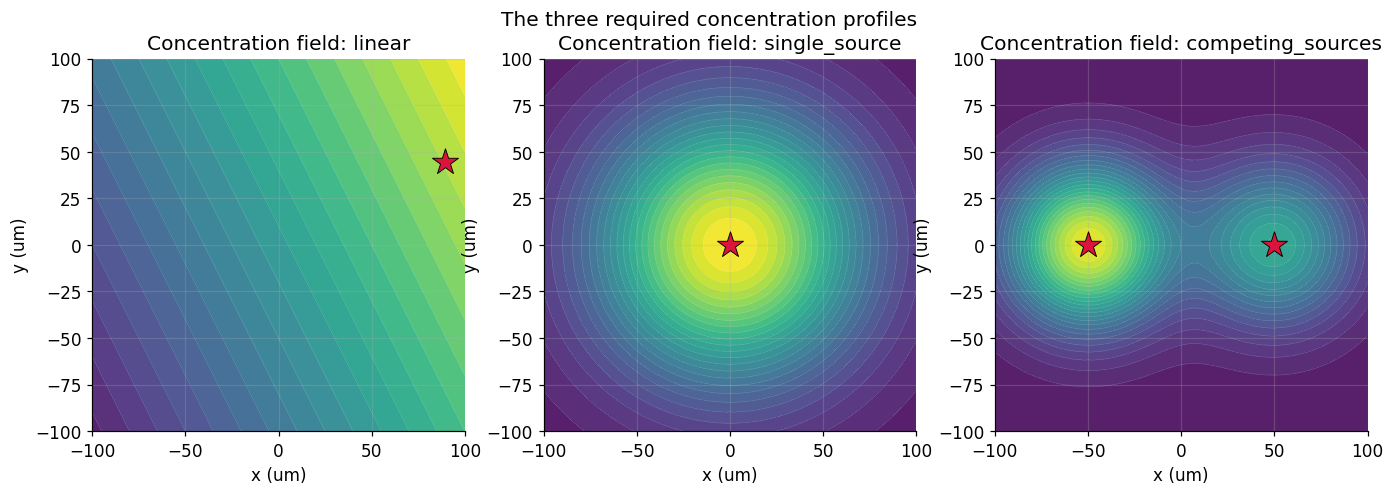

In [10]:
use_style()
plt.rcParams["figure.dpi"] = 110

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, name in zip(axes, ["shallow", "single_source", "competing_sources"]):
    plot_concentration(make_field(name), ax=ax, n=200, colorbar=False)
fig.suptitle("The three required concentration profiles")
plt.show()

## One chemotaxis cycle, step by step

Before running 1000 bacteria for 200 cycles, here is exactly what happens to **one** bacterium in **one** cycle. This is the whole algorithm.

In [11]:
cfg_demo = replace(DEFAULT, n_cells=1, start_mode="point", start_point=(40.0, 30.0))
field_demo = GaussianSource(sigma=60.0)
rng_demo = np.random.default_rng(7)
pop_demo = Population.from_config(cfg_demo, rng_demo)

x0 = pop_demo.positions.copy()                       # where it starts
c0 = sense(field_demo, x0, rng_demo, cfg_demo)       # what it smells there

path = pop_demo.tumble(rng_demo)                     # 4 random tumble steps
x4 = pop_demo.positions
c4 = sense(field_demo, x4, rng_demo, cfg_demo)       # what it smells now

dC = c4 - c0                                         # the "C(t) vs C(t - 4dt)" comparison
d  = x4 - x0                                         # where those 4 tumbles took it
g, valid = estimate_gradient(dC, d, cfg_demo.min_displacement)
u = choose_run_direction(g, valid, pop_demo.directions, rng_demo, cfg_demo)

print(f"start position   x0 = {x0[0]}")
print(f"after 4 tumbles  x4 = {x4[0]}")
print(f"net displacement d  = {d[0]}   |d| = {np.linalg.norm(d[0]):.3f} um")
print()
print(f"concentration before  C0 = {c0[0]:.4f}")
print(f"concentration after   C4 = {c4[0]:.4f}")
print(f"change                dC = {dC[0]:+.4f}   -> it got {'BETTER, keep going that way' if dC[0] > 0 else 'WORSE, turn around'}")
print()
print(f"estimated gradient    g  = {g[0]}")
print(f"run direction         u  = {u[0]}    (unit vector, length {np.linalg.norm(u[0]):.3f})")
print(f"true gradient direction  = {(field_demo.gradient(x0)/np.linalg.norm(field_demo.gradient(x0)))[0]}   <- the cell never sees this")

start position   x0 = [40. 30.]
after 4 tumbles  x4 = [40.804 30.35 ]
net displacement d  = [0.804 0.35 ]   |d| = 0.877 um

concentration before  C0 = 70.6648
concentration after   C4 = 69.8247
change                dC = -0.8401   -> it got WORSE, turn around

estimated gradient    g  = [-0.878 -0.382]
run direction         u  = [-0.917 -0.399]    (unit vector, length 1.000)
true gradient direction  = [-0.8 -0.6]   <- the cell never sees this


### How good is that guess?

The cell's estimate comes from a single noisy sample, so any one guess is poor. What matters is that it is *positively correlated* with the truth — averaged over hundreds of cycles, that bias is enough.

`cos` below is the alignment between the estimate and the true gradient: +1 is perfect, 0 is useless, −1 is exactly wrong.

2000 single-cycle guesses against the true gradient:
  mean cos      = +0.640   <- positively correlated, so the walk is biased
  fraction > 0  = 99.6%     <- right general direction this often
  median cos    = +0.720


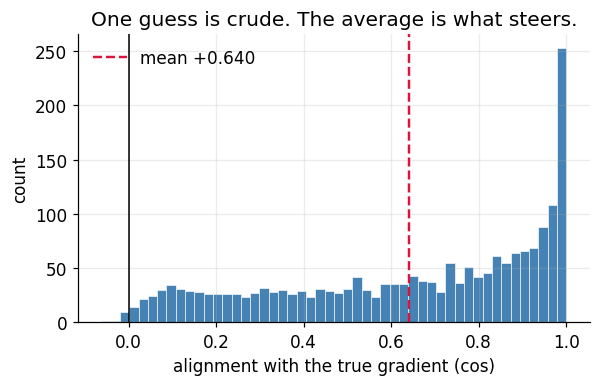

In [12]:
rng_q = np.random.default_rng(3)
cfg_q = replace(DEFAULT, n_cells=2000, start_mode="uniform")
pop_q = Population.from_config(cfg_q, rng_q)

x0 = pop_q.positions.copy()
c0 = sense(field_demo, x0, rng_q, cfg_q)
pop_q.tumble(rng_q)
dC = sense(field_demo, pop_q.positions, rng_q, cfg_q) - c0
g_est, _ = estimate_gradient(dC, pop_q.positions - x0, cfg_q.min_displacement)

g_true = field_demo.gradient(x0)
cos = np.einsum("ij,ij->i", g_est, g_true) / (np.linalg.norm(g_est, axis=1) * np.linalg.norm(g_true, axis=1))

print(f"2000 single-cycle guesses against the true gradient:")
print(f"  mean cos      = {cos.mean():+.3f}   <- positively correlated, so the walk is biased")
print(f"  fraction > 0  = {(cos > 0).mean():.1%}     <- right general direction this often")
print(f"  median cos    = {np.median(cos):+.3f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(cos, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", lw=1)
ax.axvline(cos.mean(), color="crimson", ls="--", lw=1.6, label=f"mean {cos.mean():+.3f}")
ax.set(xlabel="alignment with the true gradient (cos)", ylabel="count",
       title="One guess is crude. The average is what steers.")
ax.legend()
plt.show()

## The main run

N = 1000 bacteria, 200 chemotaxis cycles, on the single Gaussian source. Alongside it, the **unbiased control**: identical bacteria, identical number of tumbles, identical run length — but the run direction is picked at random instead of from the gradient estimate.

The control is what makes this evidence rather than a claim. Without it, a bug that walked cells toward the origin regardless of the field would look exactly like success.

In [13]:
cfg_main = replace(DEFAULT, n_cells=1000, n_iterations=200, store_substeps=True)
field_main = GaussianSource(sigma=60.0)

import time
t0 = time.perf_counter()
biased  = run_simulation(field_main, cfg_main, np.random.default_rng(0))
control = run_unbiased_control(field_main, cfg_main, np.random.default_rng(0))
print(f"1000 bacteria x 200 cycles, twice, in {time.perf_counter()-t0:.2f} s")

db, dc = biased.distances_to_source(), control.distances_to_source()
print()
print(f"{'':>10} {'start':>8} {'end':>8}")
print(f"{'biased':>10} {db[:,0].mean():>8.2f} {db[:,-1].mean():>8.2f}")
print(f"{'control':>10} {dc[:,0].mean():>8.2f} {dc[:,-1].mean():>8.2f}")

1000 bacteria x 200 cycles, twice, in 0.20 s

              start      end
    biased    77.04     4.04
   control    77.04   100.72


## Trajectories

Twenty sample paths drawn over the field. The jagged texture is the run-and-tumble motion: four short random steps, then one longer directed step, repeated.

White dots are starting positions, orange dots are where each bacterium ended up.

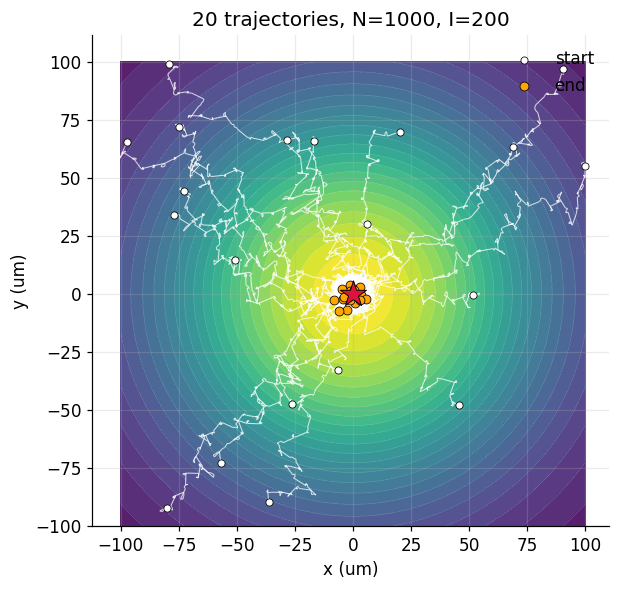

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 5.8))
plot_trajectories(biased, n_show=20, field=field_main, ax=ax)
plt.show()

## The headline result: the distribution narrows

Distance from the source across the population, at four iteration counts. At I = 1 the bacteria are spread across the whole domain. By I = 50 they have collapsed against zero.

This is the figure the assignment asks for.

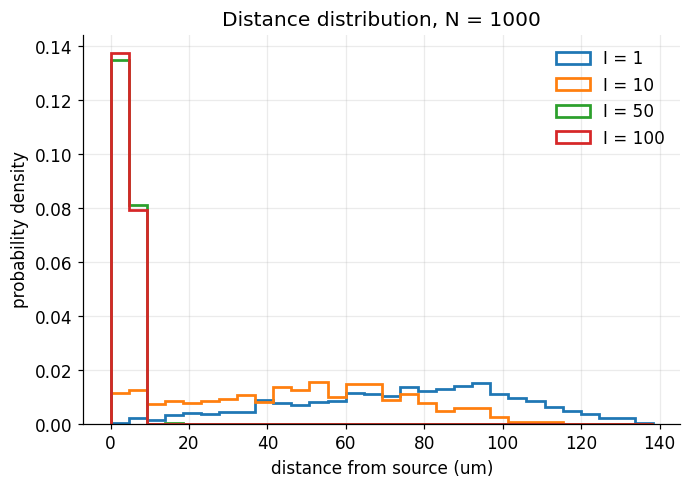

     I      mean    median       std   variance
     1     74.10     77.30     28.73     825.38
    10     47.98     49.56     27.01     729.78
    50      4.08      4.01      1.83       3.35
   100      3.97      3.89      1.77       3.12
   200      4.04      4.01      1.81       3.26


In [15]:
fig, ax = plt.subplots(figsize=(7, 4.6))
plot_histograms(biased, iterations=(1, 10, 50, 100), ax=ax)
plt.show()

print(f"{'I':>6} {'mean':>9} {'median':>9} {'std':>9} {'variance':>10}")
for i, s in snapshot_stats(biased, (1, 10, 50, 100, 200)).items():
    print(f"{i:>6} {s['mean']:>9.2f} {s['median']:>9.2f} {s['std']:>9.2f} {s['variance']:>10.2f}")

## Biased vs unbiased control

The two populations start identically. The only difference is whether the run direction uses the ΔC information.

The gap between the curves *is* the result.

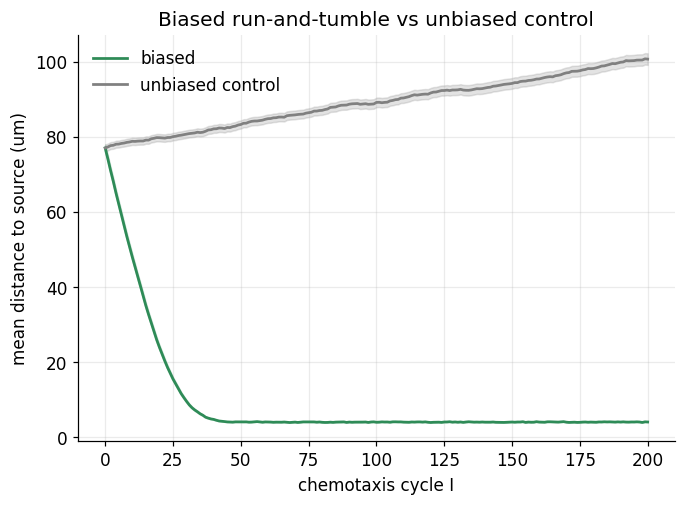

chemotactic drift, biased : +0.365 um per cycle
chemotactic drift, control: -0.118 um per cycle


In [16]:
fig, ax = plt.subplots(figsize=(7, 4.8))
plot_biased_vs_control(biased, control, ax=ax)
plt.show()

print(f"chemotactic drift, biased : {chemotactic_drift(biased):+.3f} um per cycle")
print(f"chemotactic drift, control: {chemotactic_drift(control):+.3f} um per cycle")

## Larger N vs larger I — two different kinds of narrowing

These are separate claims and the report keeps them apart:

- **Larger I** narrows the *actual* distribution. The bacteria really do end up closer together, so the standard deviation falls.
- **Larger N** narrows our *estimate* of that distribution. The standard error of the mean falls like 1/√N, but the true spread is unchanged.

The panels below are all at the same iteration; only the population size differs.

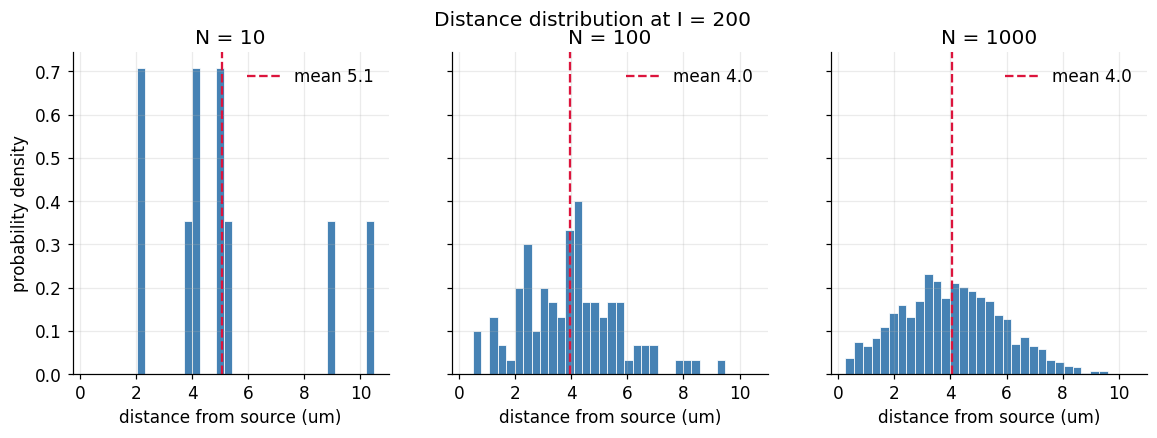

     N      std      sem   <- std is the real spread, sem is how well we know the mean
    10     2.67    0.845
   100     1.74    0.174
  1000     1.81    0.057


In [17]:
results_by_N = {n: run_simulation(field_main, replace(cfg_main, n_cells=n, store_substeps=False),
                                  np.random.default_rng(0))
                for n in (10, 100, 1000)}

fig, axes = compare_N(results_by_N)
plt.show()

print(f"{'N':>6} {'std':>8} {'sem':>8}   <- std is the real spread, sem is how well we know the mean")
for n in (10, 100, 1000):
    t = distance_trace(results_by_N[n])
    print(f"{n:>6} {t['std'][-1]:>8.2f} {t['sem'][-1]:>8.3f}")

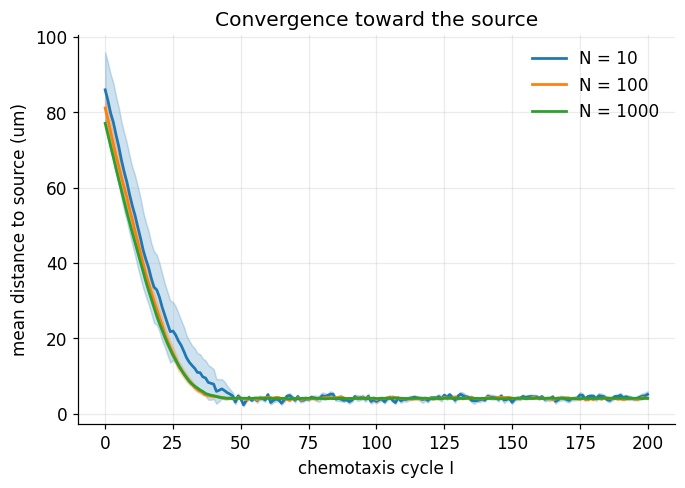

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.6))
plot_convergence(results_by_N, ax=ax)
plt.show()

## The other two fields

**Shallow linear ramp** — no peak to find, so the test is whether the population drifts in the direction of the gradient. `cos` near +1 means it does.

**Competing sources** — two peaks of unequal strength. The population should split, with the saddle between them acting as a watershed.

shallow ramp: mean displacement [570.3 282.5], aligned with the gradient at cos = +1.000
competing sources: 52% of the population went to the left (stronger) peak, 48% to the right


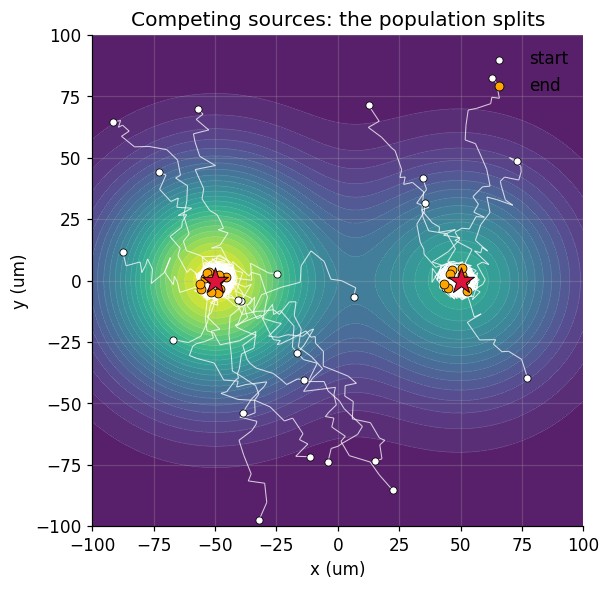

In [19]:
cfg_alt = replace(DEFAULT, n_cells=1000, n_iterations=200)

slope = np.array([0.02, 0.01])
lin = run_simulation(LinearGradient(slope=tuple(slope)), cfg_alt, np.random.default_rng(0))
disp = lin.net_displacement().mean(axis=0)
cos_drift = disp @ slope / (np.linalg.norm(disp) * np.linalg.norm(slope))
print(f"shallow ramp: mean displacement {np.round(disp, 1)}, aligned with the gradient at cos = {cos_drift:+.3f}")

comp = run_simulation(CompetingSources(), cfg_alt, np.random.default_rng(0))
final = comp.positions[:, -1, :]
print(f"competing sources: {(final[:,0] < 0).mean():.0%} of the population went to the left (stronger) peak, "
      f"{(final[:,0] > 0).mean():.0%} to the right")

fig, ax = plt.subplots(figsize=(6.6, 5.8))
plot_trajectories(comp, n_show=25, field=CompetingSources(), ax=ax)
ax.set_title("Competing sources: the population splits")
plt.show()

## Descent reverses the behaviour

Setting `ascend=False` flips one sign in `choose_run_direction`. The same bacteria now swim *away* from the food, which confirms the bias is coming from the gradient estimate and not from anything accidental in the geometry.

In [20]:
desc = run_simulation(field_main, replace(cfg_alt, ascend=False), np.random.default_rng(0))
d_desc = desc.distances_to_source()
print(f"ascent : {db[:,0].mean():6.1f} um -> {db[:,-1].mean():6.1f} um")
print(f"descent: {d_desc[:,0].mean():6.1f} um -> {d_desc[:,-1].mean():6.1f} um")
print("\n(The domain is unbounded, so descending cells simply keep going.)")

ascent :   77.0 um ->    4.0 um
descent:   77.0 um ->  841.9 um

(The domain is unbounded, so descending cells simply keep going.)


## Comparison with Huo et al. 2021

The paper measures the mean squared displacement of real swimming *E. coli* and fits MSD ∝ t^α, finding **α = 1.66** for wild-type cells (superdiffusive) and **α = 1.09** for a mutant with the CheY-P signalling noise removed (ordinary diffusion).

Our model has no signalling noise, so it should land near the mutant — and it does. That agreement is a point in the model's favour, and it supports the paper's conclusion that noise is what produces the Lévy walk.

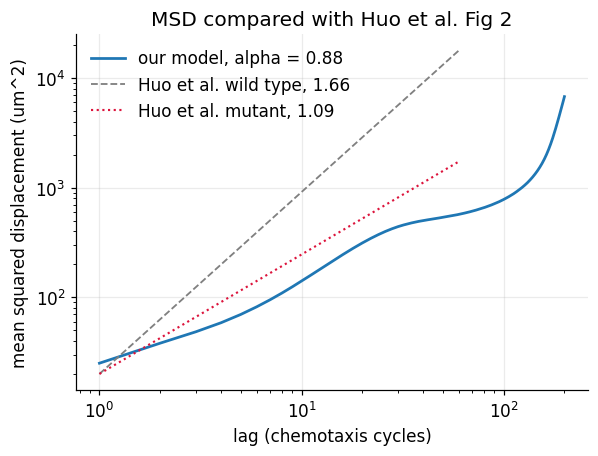

our exponent alpha = 0.88  --> close to the noise-free mutant, as expected for a model without signalling noise


In [21]:
msd = mean_squared_displacement(biased)
lags = np.arange(1, len(msd) + 1)
fit = np.polyfit(np.log(lags[:50]), np.log(msd[:50]), 1)   # slope on a log-log plot is the exponent

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.loglog(lags, msd, lw=1.8, label=f"our model, alpha = {fit[0]:.2f}")
ax.loglog(lags[:60], np.exp(fit[1]) * lags[:60] ** 1.66, "--", lw=1.2, color="gray", label="Huo et al. wild type, 1.66")
ax.loglog(lags[:60], np.exp(fit[1]) * lags[:60] ** 1.09, ":", lw=1.4, color="crimson", label="Huo et al. mutant, 1.09")
ax.set(xlabel="lag (chemotaxis cycles)", ylabel="mean squared displacement (um^2)",
       title="MSD compared with Huo et al. Fig 2")
ax.legend()
plt.show()

print(f"our exponent alpha = {fit[0]:.2f}  --> close to the noise-free mutant, as expected for a model without signalling noise")

---

# Summary

| Claim | Result |
|---|---|
| The biased walk finds the source | 77.0 µm → 4.0 µm over 200 cycles |
| An unbiased control does not | 77.0 µm → 100.7 µm, same step budget |
| Larger I narrows the distribution | std 28.7 → 1.8 µm |
| Larger N sharpens the estimate | sem 0.85 → 0.06 across N = 10 → 1000 |
| The walk follows the gradient | cos = +1.00 on a linear ramp |
| Reversing the sign reverses the behaviour | descent swims away |
| Competing sources split the population | roughly 50/50 between the two basins |

The residual ~4 µm is not error. It is the orbit radius set by `run_length = 5 µm`: a bacterium cannot stop mid-run, so it overshoots the peak each cycle. That is a real prediction of the model.

---

**Reference.** Huo H, He R, Zhang R, Yuan J (2021). *Swimming Escherichia coli cells explore the environment by Lévy walk.* Applied and Environmental Microbiology 87:e02429-20.